In [ ]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn.objects as so

In [ ]:
plt.rcParams["font.size"] = 14
pd.options.display.float_format = "{:.3f}".format

In [ ]:
def get_number_of_instructions(circuit_name: str) -> int:
    with open(f"../../data/circuit/{circuit_name}.in") as f:
        lines = f.readlines()
    return sum(bool(line) for line in lines)

In [ ]:
def load_and_modify(csv_name):
    df = pd.read_csv(csv_name)
    instruction_count = {
        c: get_number_of_instructions(c) for c in df["circuit"].unique()
    }
    df["instruction_count"] = df["circuit"].map(instruction_count)
    df["cbpi"] = df["total_code_beat"] / df["instruction_count"]
    df["cvpi"] = df["circuit_volume"] / df["instruction_count"]
    df["architecture"] = (
        df["layer_count"].map({1: "2D", 2: "2.5D"}) + " " + df["factory"]
    )
    df["allocator_msf"] = df["allocator"] + " " + df["msf_coeff"].astype(str)
    return df

In [ ]:
def extract_best_sa(df):
    idx = df.groupby(
        [
            "circuit",
            "factory",
            "layer_count",
            "allocator",
            "routing_algo",
            "routing_option",
            "msf_prep_time",
        ]
    )["total_code_beat"].idxmin()
    return df.loc[idx]

In [ ]:
order_info = {
    "architecture": ["2D outer", "2D inner", "2.5D outer", "2.5D inner"],
    "allocator": ["naive", "random", "SA"],
    "routing_algo": ["Single", "Double", "Proj"],
}

option_styles = {
    "No_MSF": {"label": "Base", "color": "C0"},
    "No_Top": {"label": "Magic", "color": "C1"},
    "No_Kink": {"label": "Path", "color": "C2"},
    "Yes_Kink": {"label": "Kink", "color": "C3"},
}


def circuit_stack_plot(
    title,
    df_circuit,
    col="architecture",
    row="allocator",
    x="routing_algo",
    y="cbpi",
    order_info=order_info,
    save: bool = False,
    save_dir: str = "../../fig/cbpi_stack",
) -> None:
    if save:
        os.makedirs(save_dir, exist_ok=True)

    fig = plt.figure(figsize=(2 * len(order_info[col]) + 3, len(order_info[row]) + 3))
    p = (
        so.Plot(df_circuit, x=x, y=y)
        .facet(
            col=col,
            row=row,
            order={
                "col": order_info[col],
                "row": order_info[row],
            },
        )
        .scale(x=so.Nominal(order=order_info[x]))
    )

    for option, style in reversed(option_styles.items()):
        p = p.add(
            so.Bars(
                color=style["color"], alpha=1
            ),  # so.Dodge() を追加して棒を横に並べる
            data=df_circuit[
                df_circuit["routing_option"] == option
            ],  # 各optionでデータをフィルタ
            label=style["label"],
            # zorder=style['zorder']    # 辞書からzorderを指定
        )
    p.on(fig).plot()
    fig.suptitle(title, y=1)
    # fig.legends[0].set_bbox_to_anchor((0.95, 1))
    plt.tight_layout()
    plt.show()
    if save:
        figname = os.path.join(save_dir, title + ".png")
        fig.savefig(figname)

# CBPI Stack

## Compare MSF

In [ ]:
df_all = load_and_modify("../../out/table/Heisenberg2D_10_all.csv")
df_all_prep_2 = df_all[df_all["msf_prep_time"] == 2]

order_info_sa_all = order_info.copy()
order_info_sa_all["allocator_msf"] = [
    # "naive 0.0",
    # "random 0.0",
    "SA 0.001",
    "SA 0.01",
    "SA 0.1",
    "SA 1.0",
]


def compare_msf():
    for circuit, df_circuit in sorted(df_all_prep_2.groupby("circuit")):
        circuit_stack_plot(
            circuit,
            df_circuit,
            col="routing_algo",
            row="architecture",
            x="allocator_msf",
            order_info=order_info_sa_all,
            save=True,
            save_dir="../../fig/cbpi_stack_sns/compare_msf",
        )

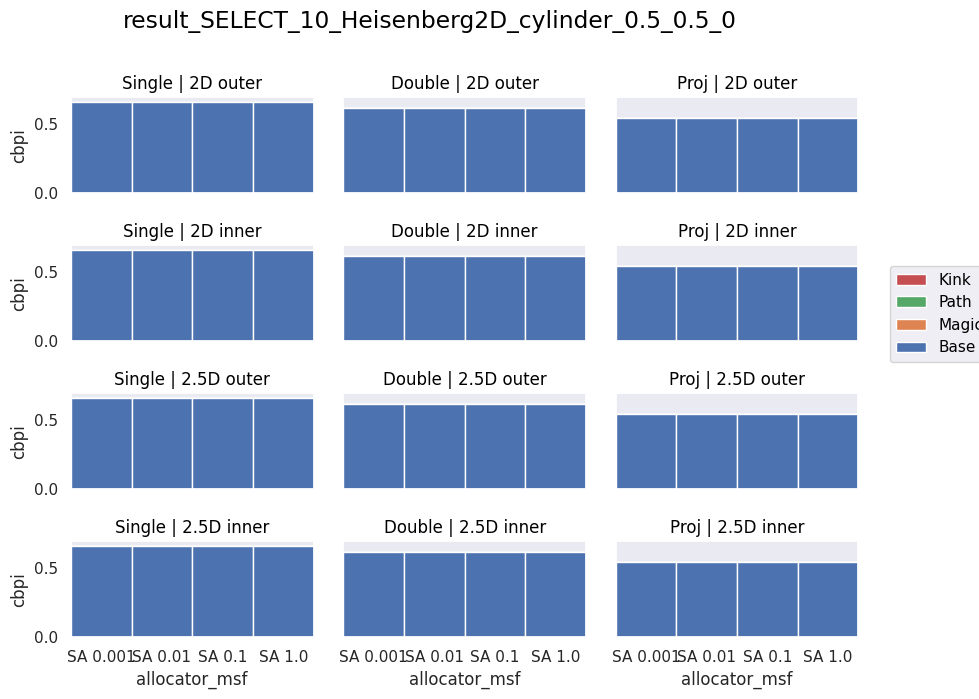

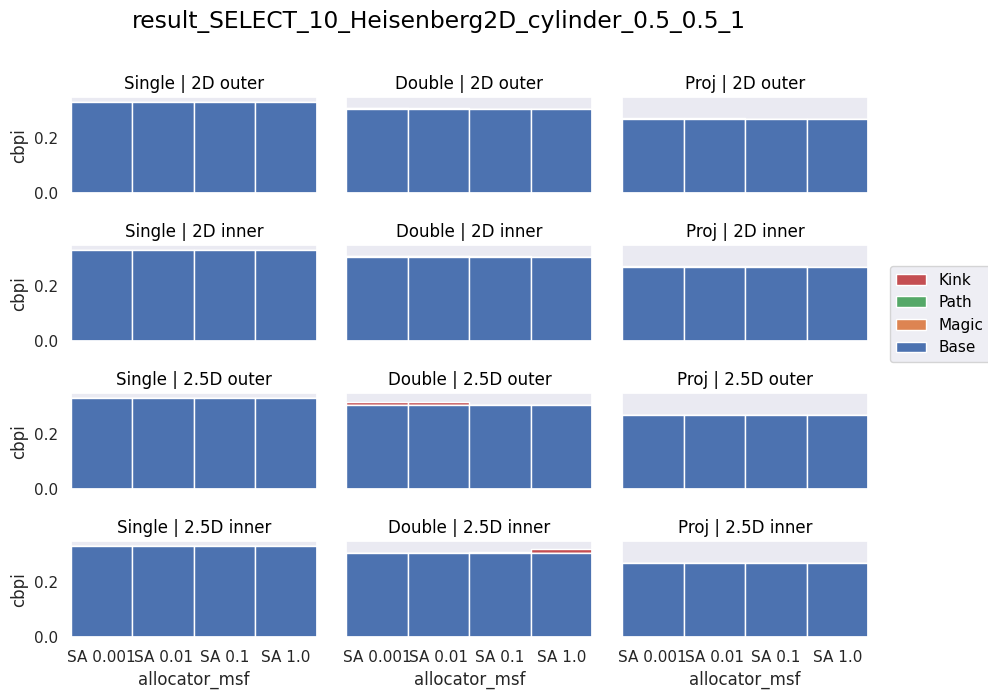

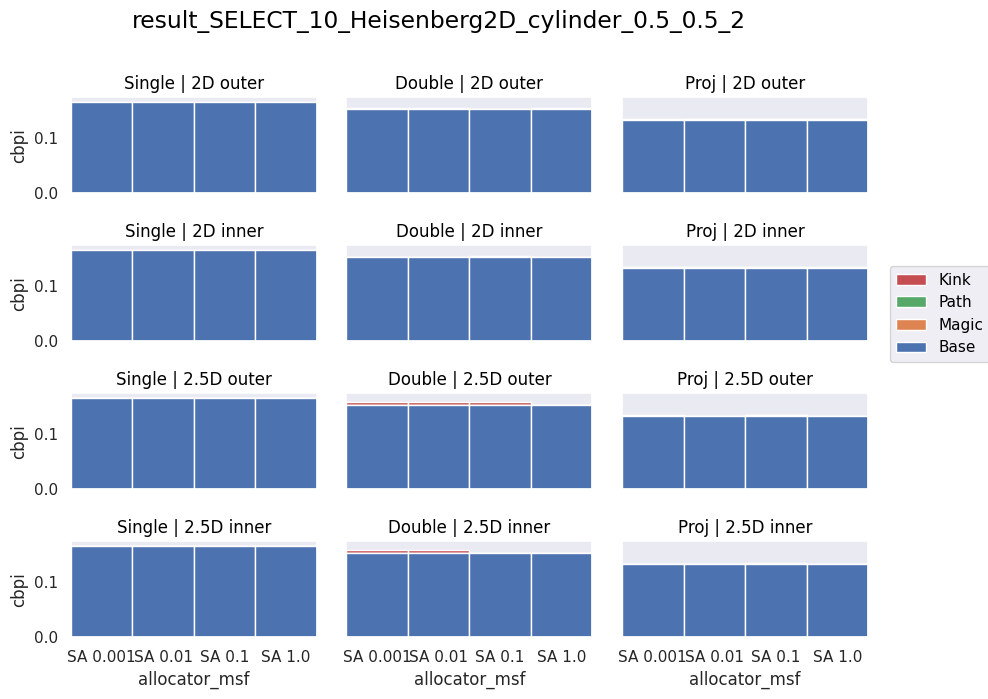

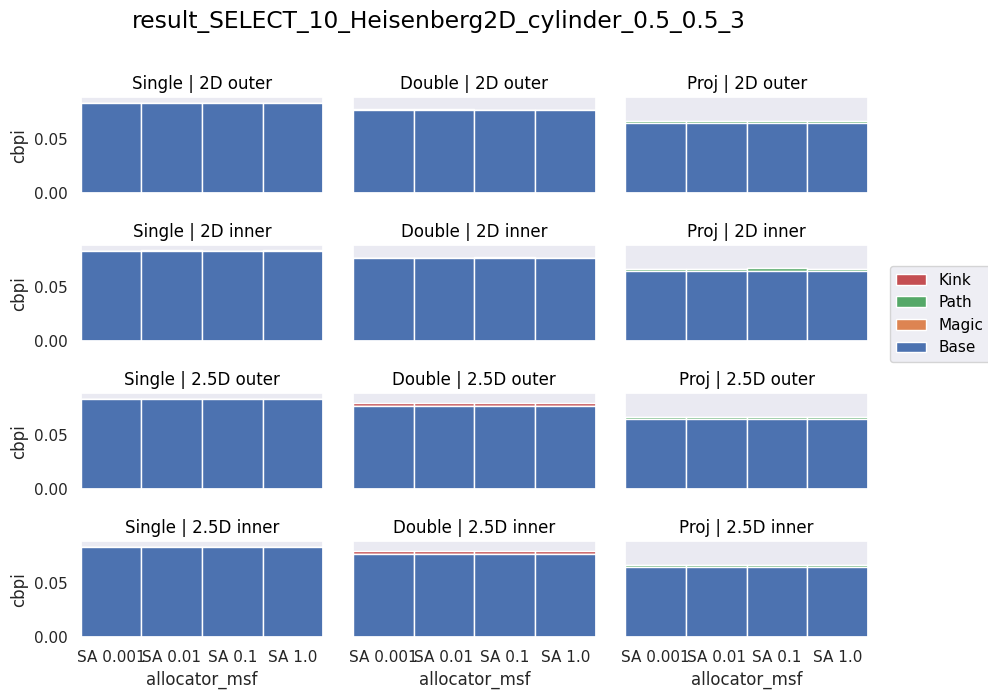

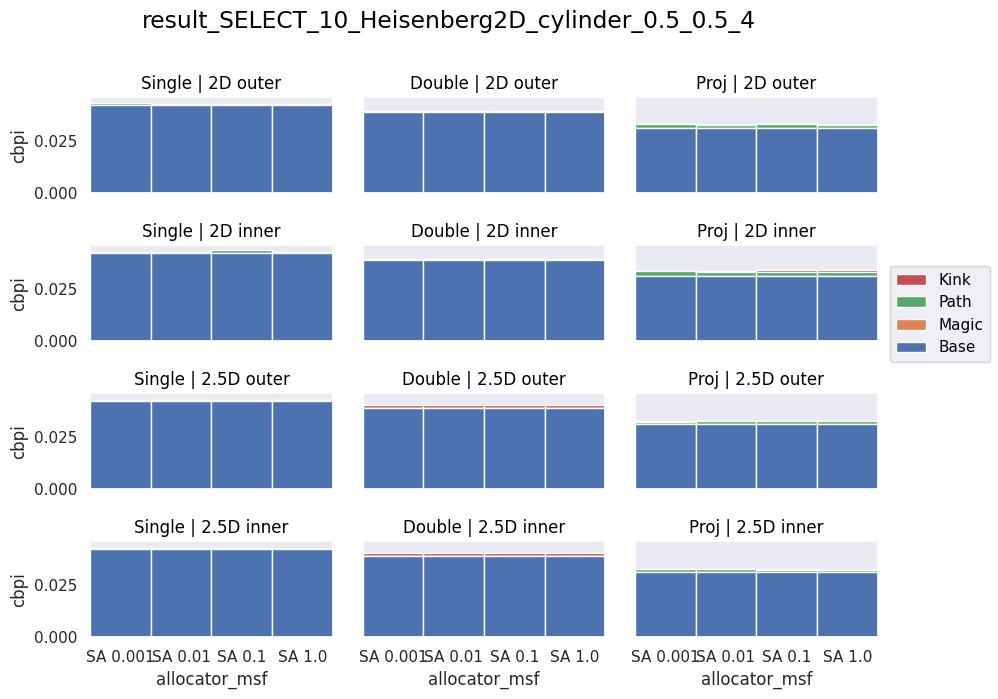

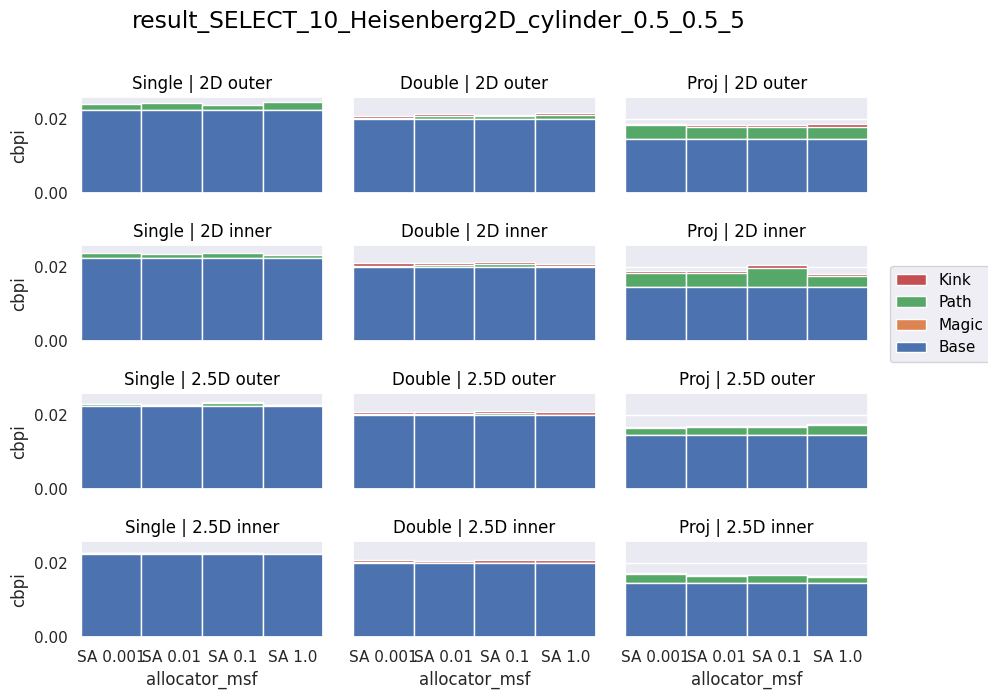

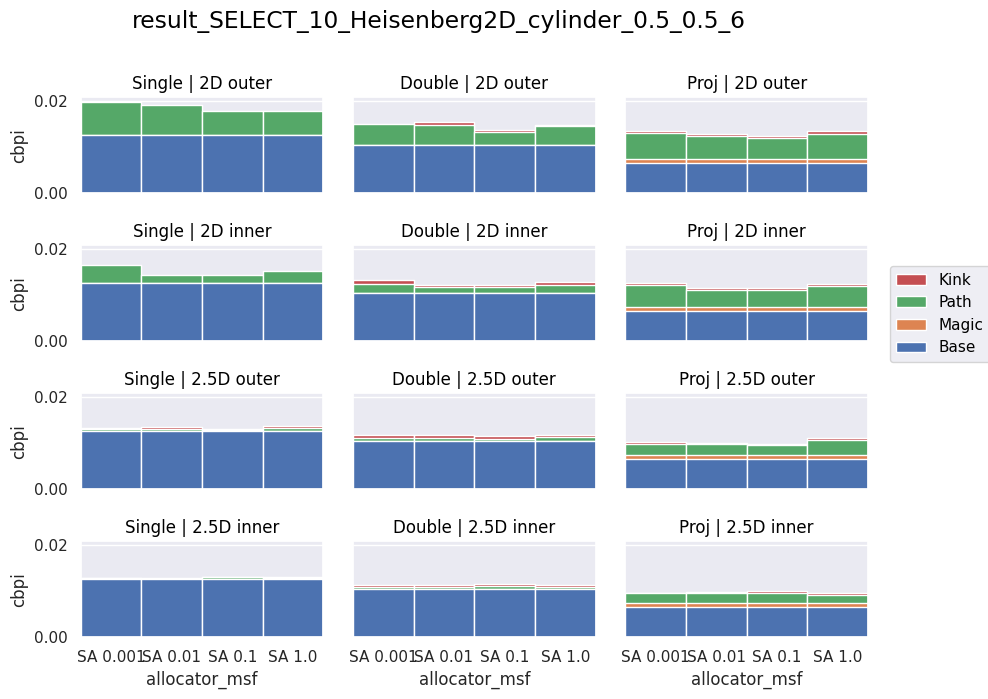

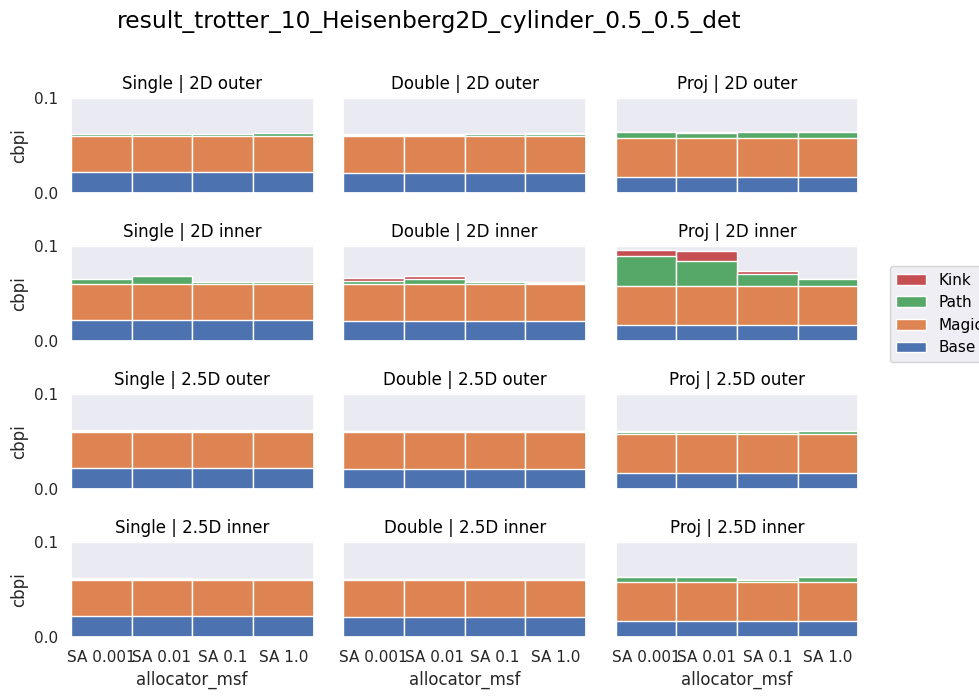

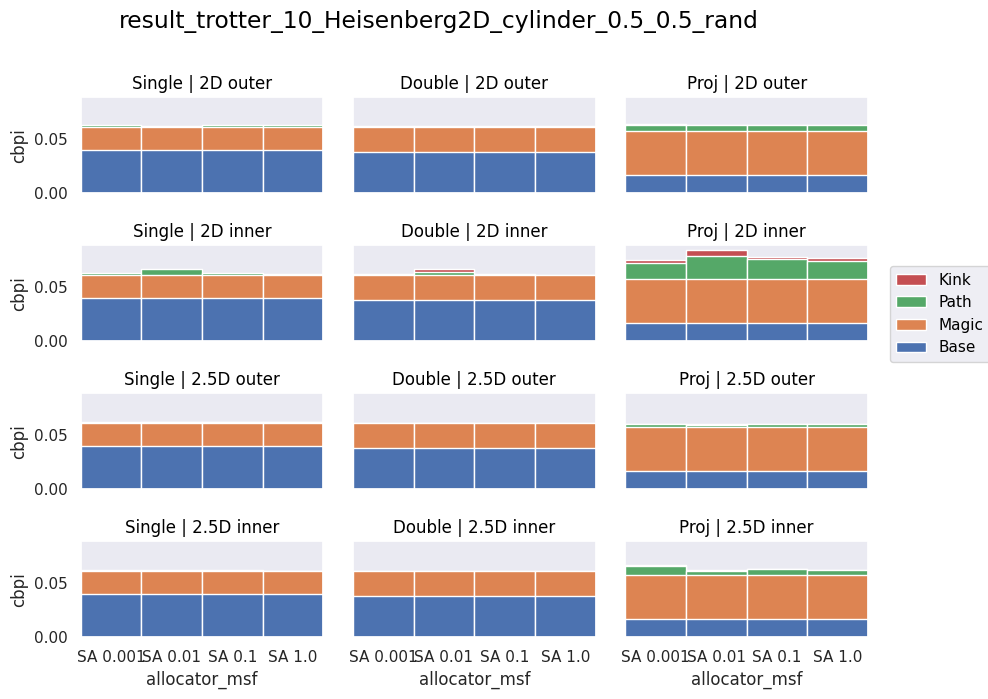

In [ ]:
compare_msf()

## Compare Each Component

In [ ]:
df_best = extract_best_sa(df_all)

df_best_prep_0 = df_best[df_best["msf_prep_time"] == 0]
df_best_prep_1 = df_best[df_best["msf_prep_time"] == 1]
df_best_prep_2 = df_best[df_best["msf_prep_time"] == 2]


order_info_sa = order_info.copy()
order_info_sa["allocator"] = ["SA"]


def compare_allocator(
    df_best_prep,
    save_dir="../../fig/cbpi_stack_sns/compare_allocator",
):
    for circuit, df_circuit in sorted(df_best_prep.groupby("circuit")):
        circuit_stack_plot(
            circuit,
            df_circuit,
            row="architecture",
            col="routing_algo",
            x="allocator",
            save=True,
            save_dir=save_dir,
        )


def compare_routing(
    df_best_prep,
    y="cbpi",
    save_dir="../../fig/cbpi_stack_sns/compare_routing",
):
    for circuit, df_circuit in sorted(df_best_prep.groupby("circuit")):
        circuit_stack_plot(
            circuit,
            df_circuit,
            y=y,
            order_info=order_info_sa,
            save=True,
            save_dir=save_dir,
        )


def compare_architecture(
    df_best_prep,
    save_dir="../../fig/cbpi_stack_sns/compare_archi",
):
    for circuit, df_circuit in sorted(df_best_prep.groupby("circuit")):
        circuit_stack_plot(
            circuit,
            df_circuit,
            col="routing_algo",
            row="allocator",
            x="architecture",
            order_info=order_info_sa,
            save=True,
            save_dir=save_dir,
        )

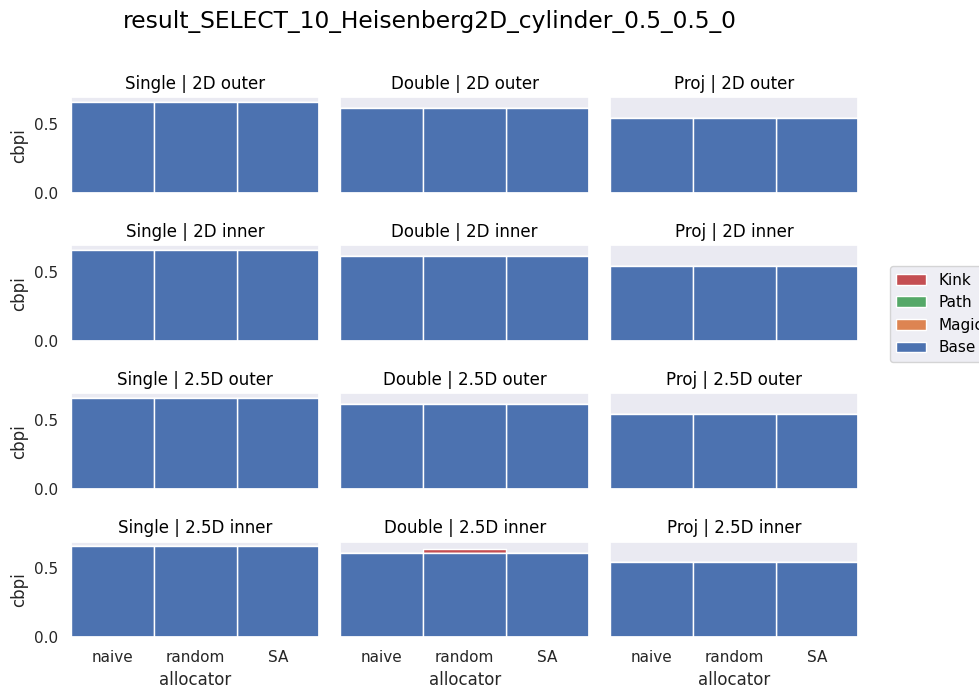

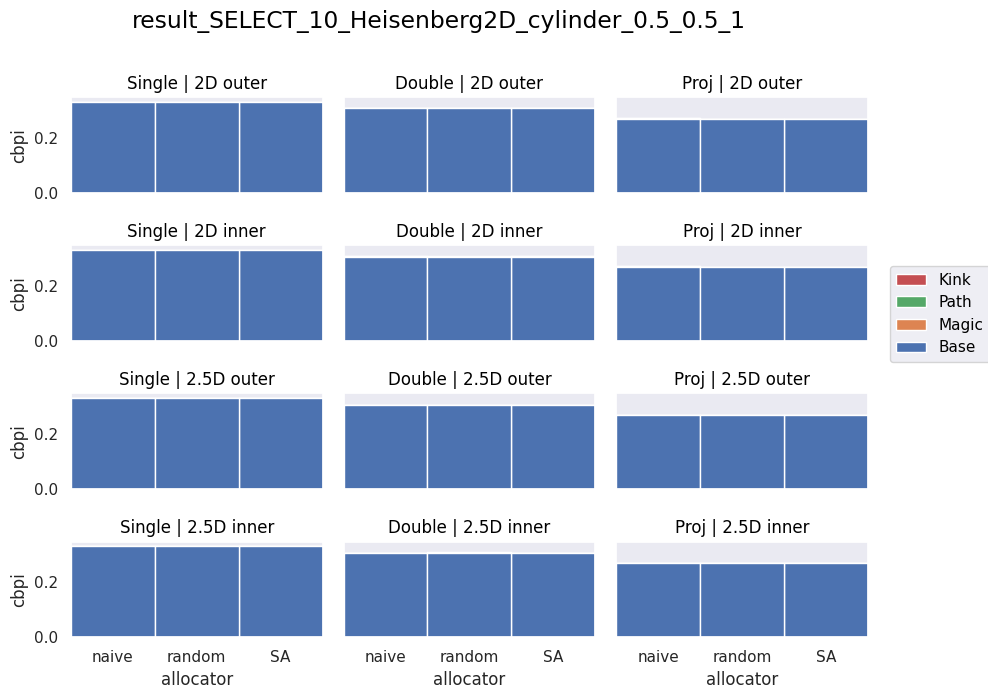

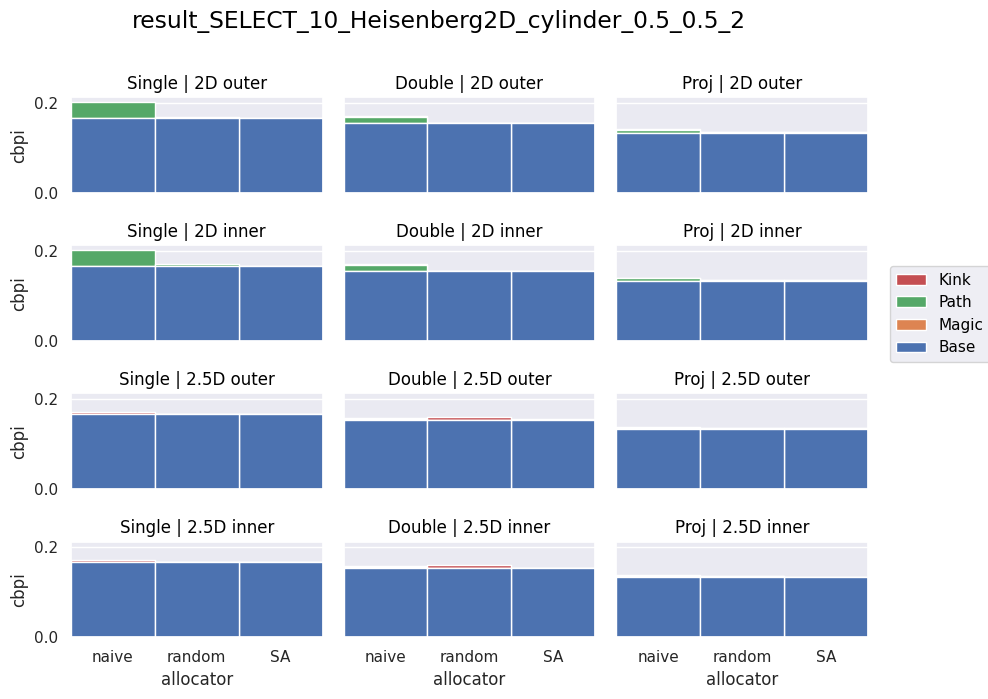

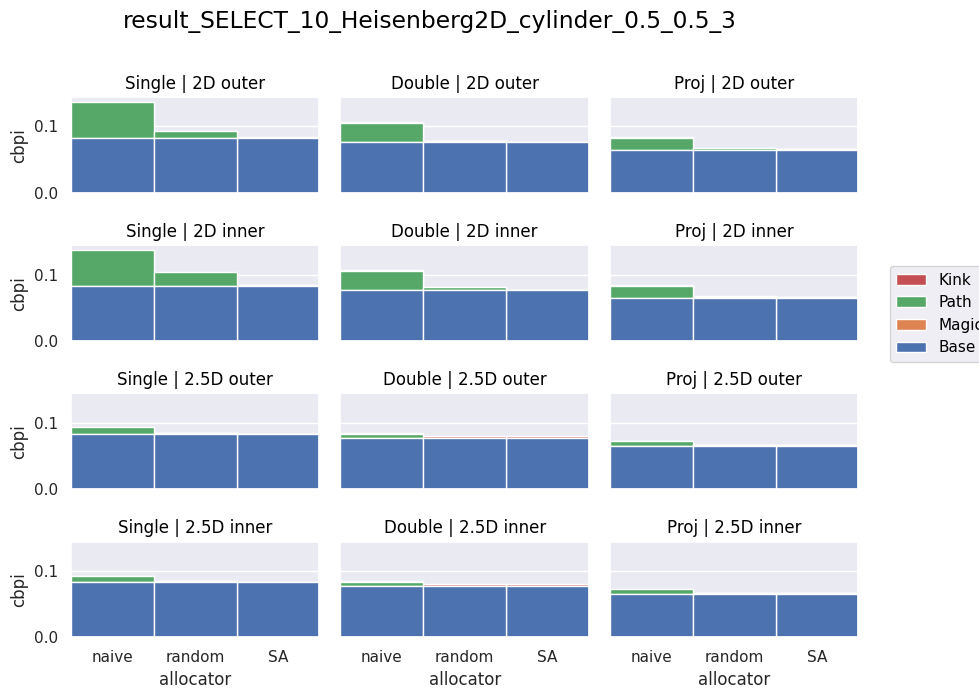

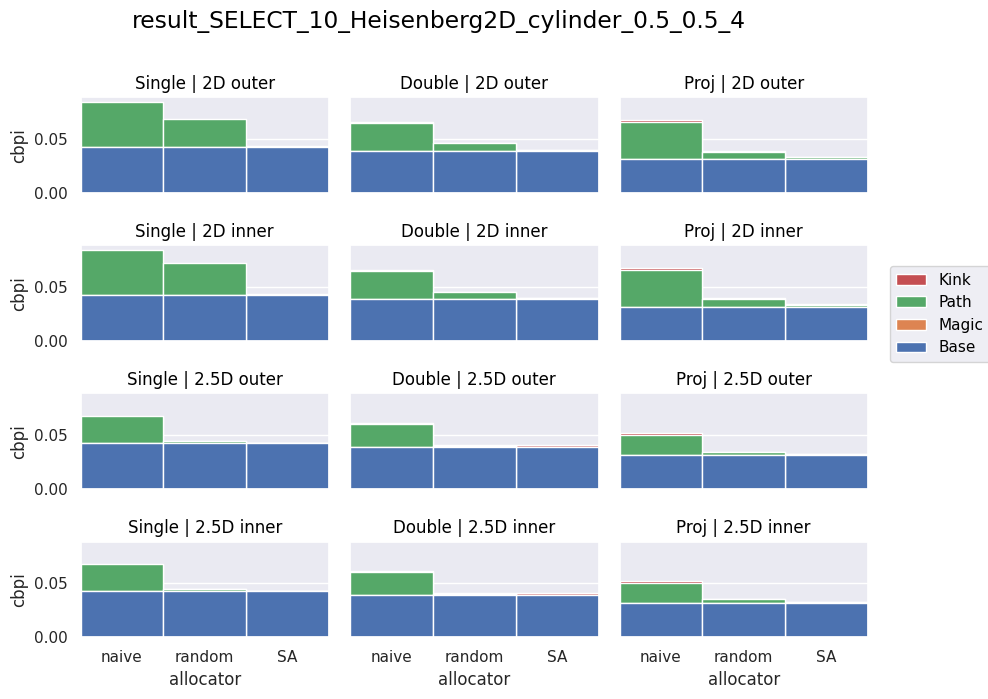

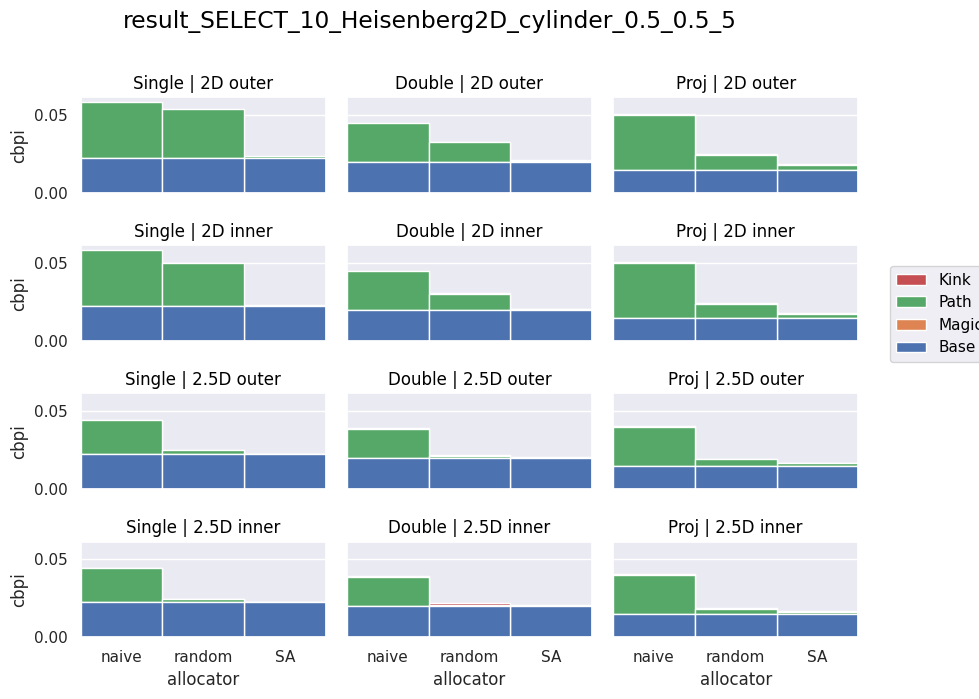

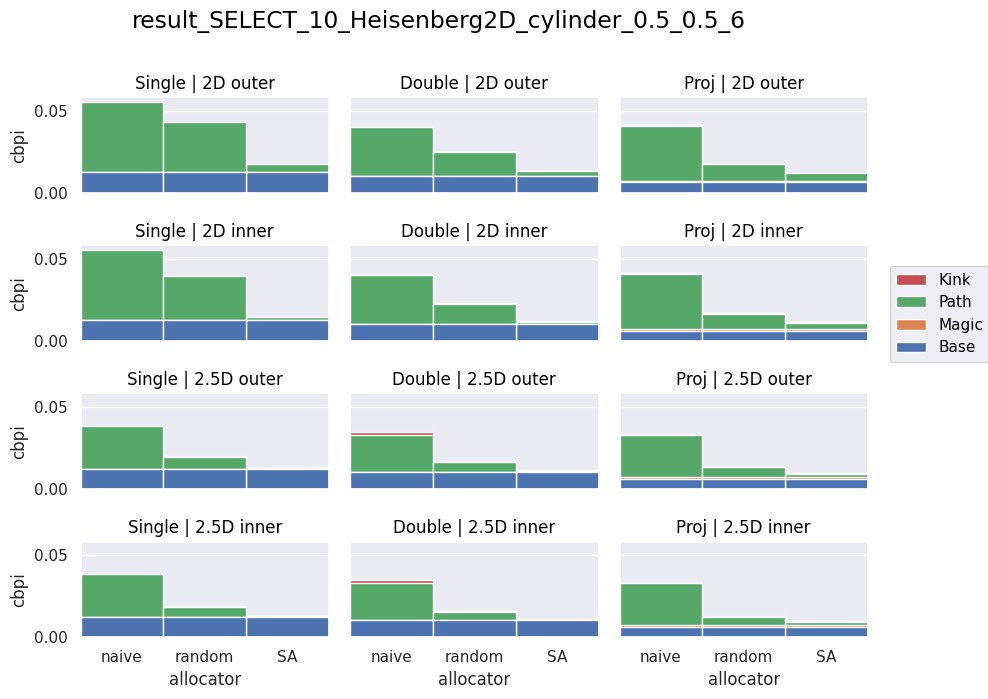

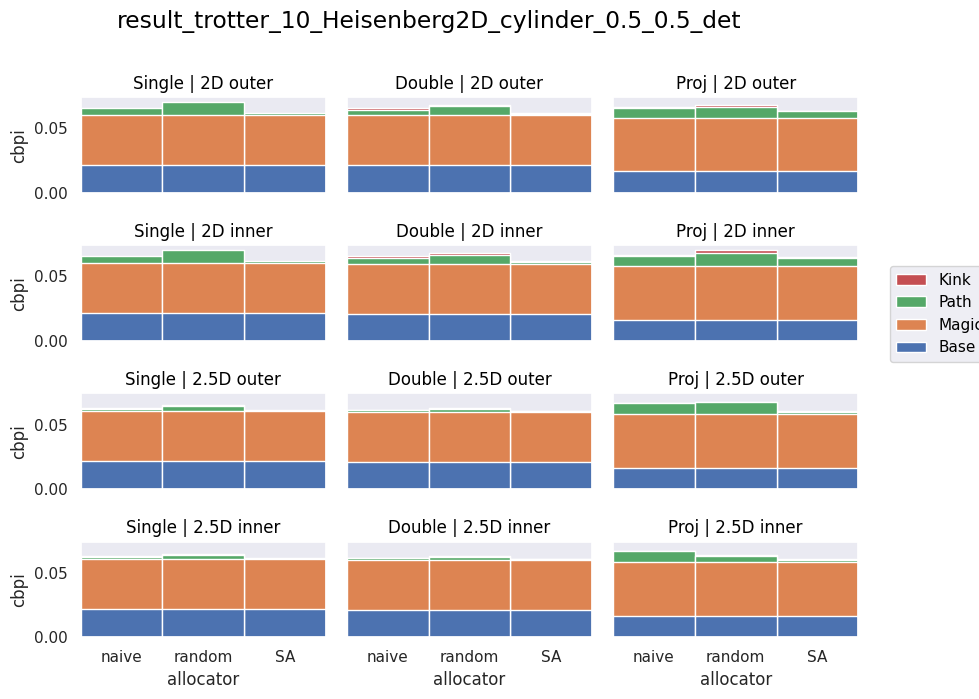

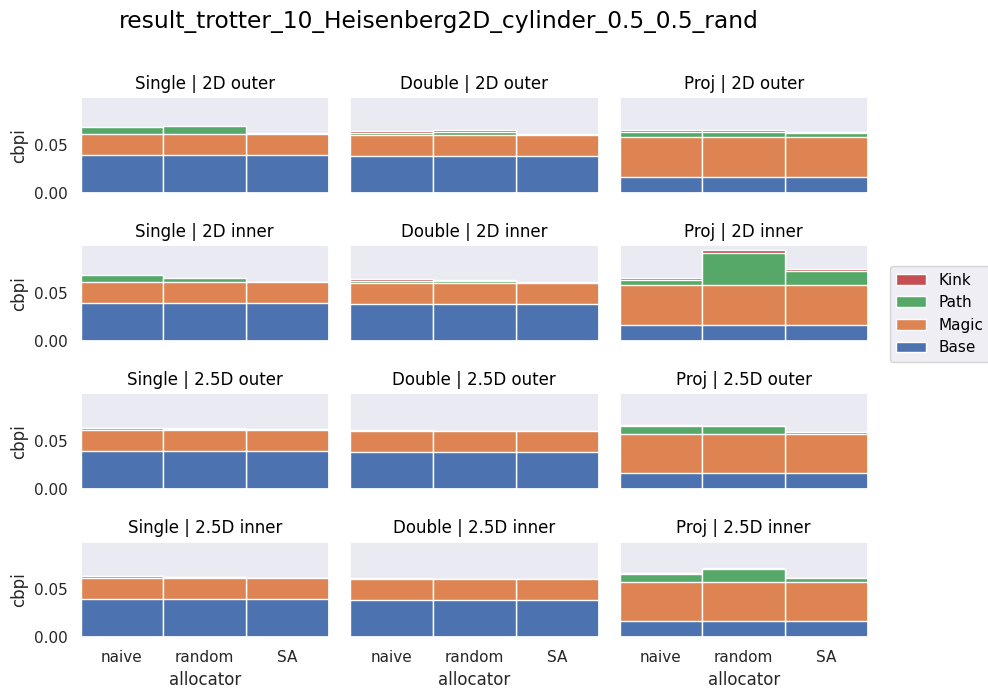

In [ ]:
compare_allocator(df_best_prep_2)

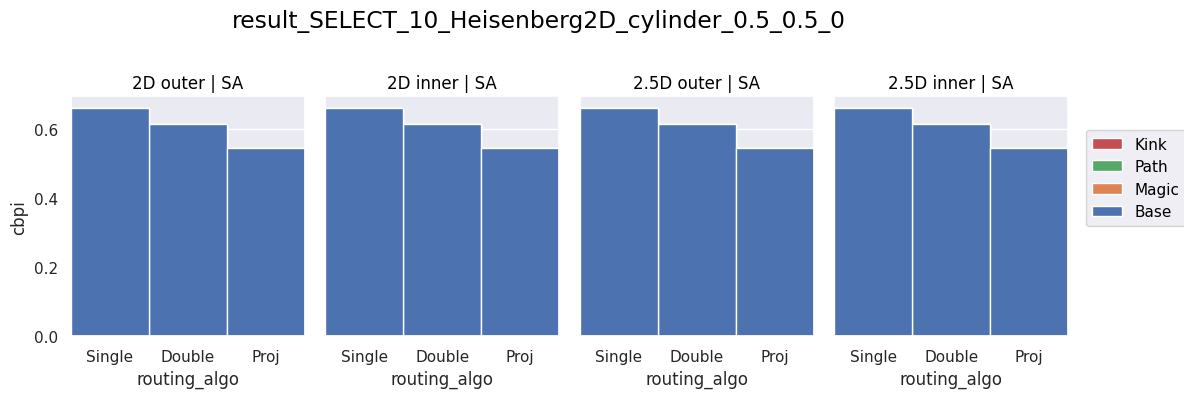

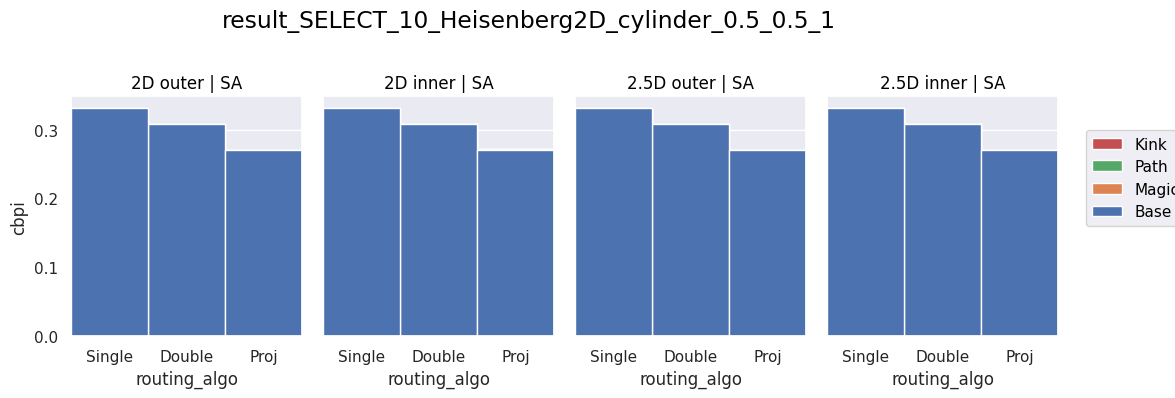

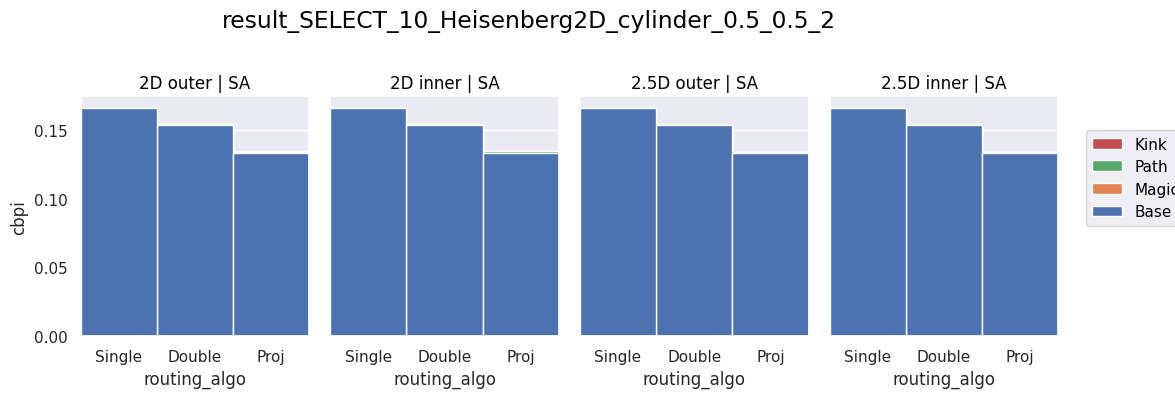

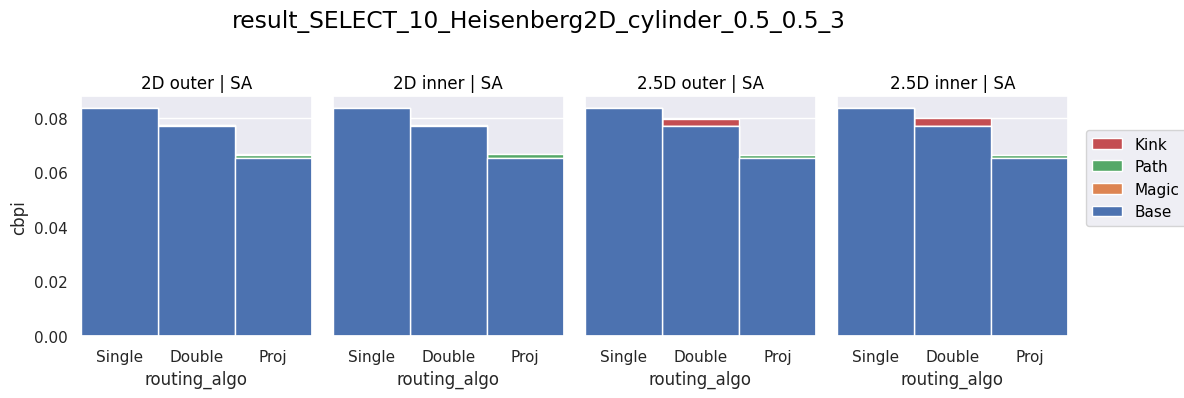

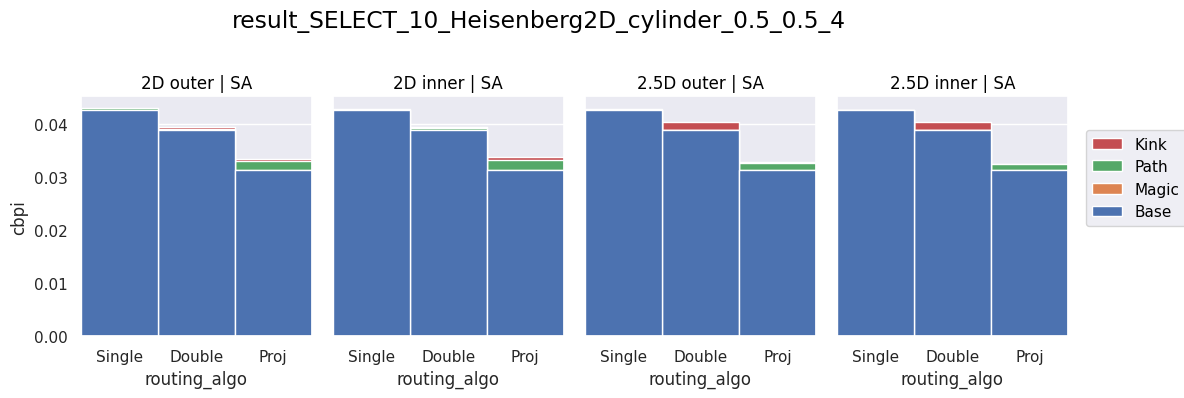

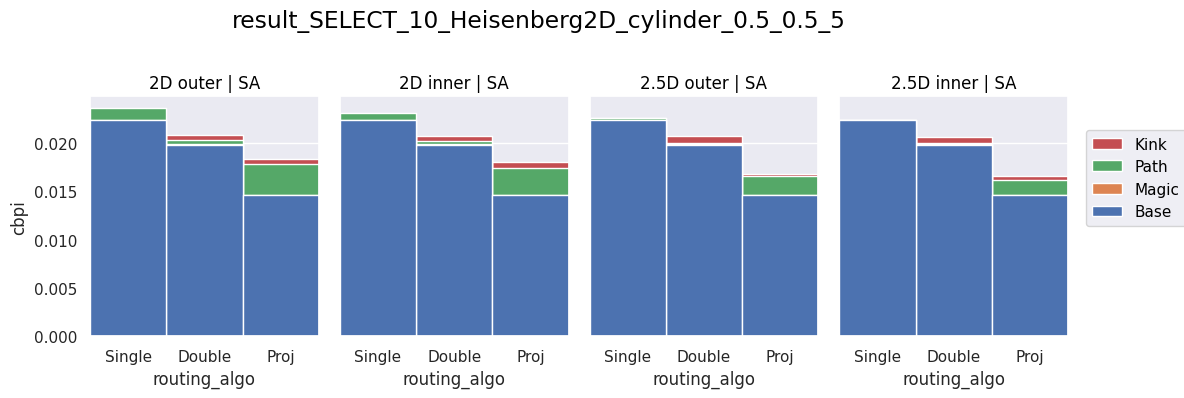

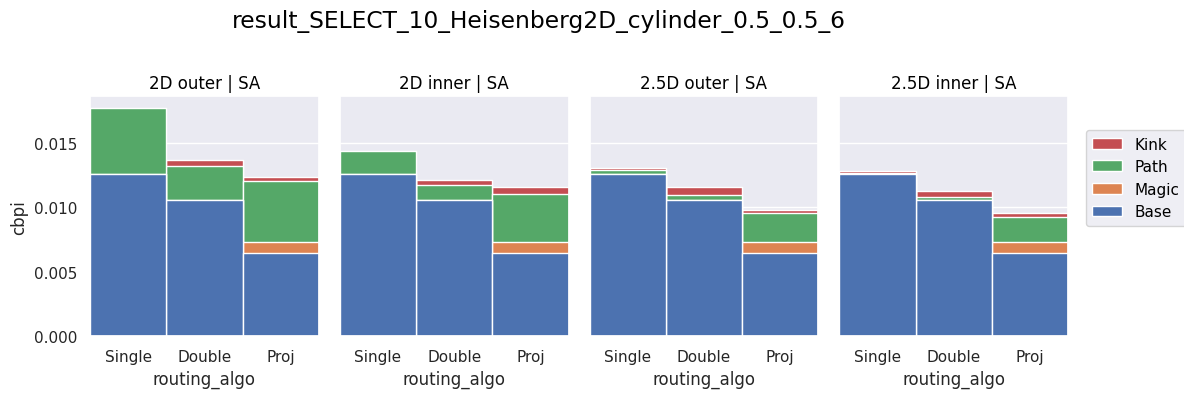

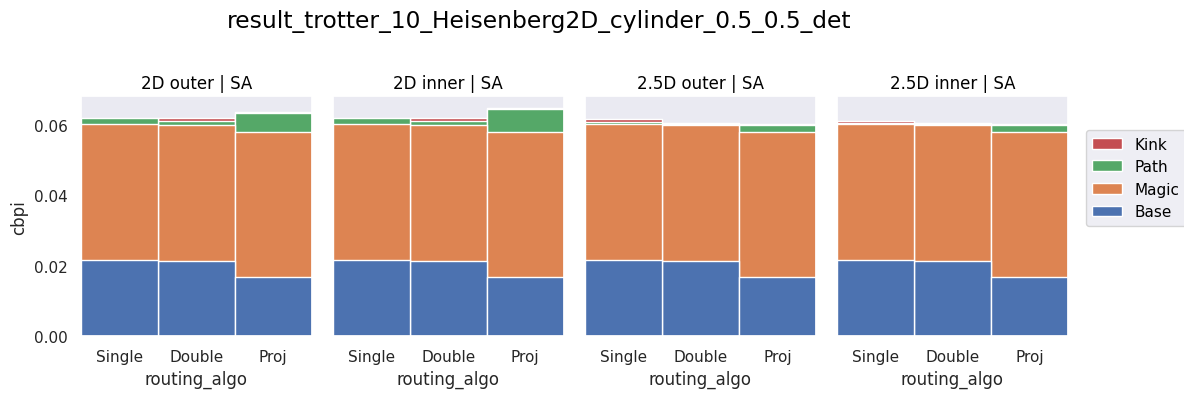

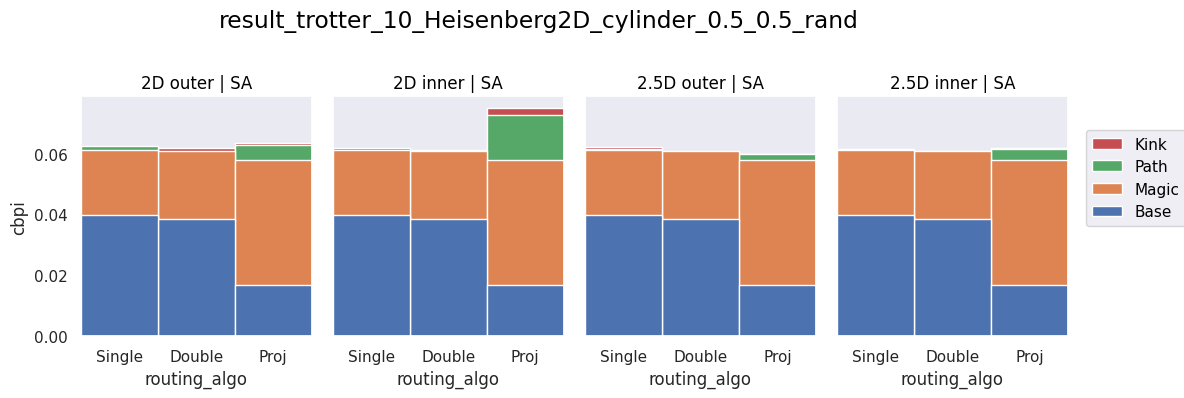

In [ ]:
compare_routing(df_best_prep_2)

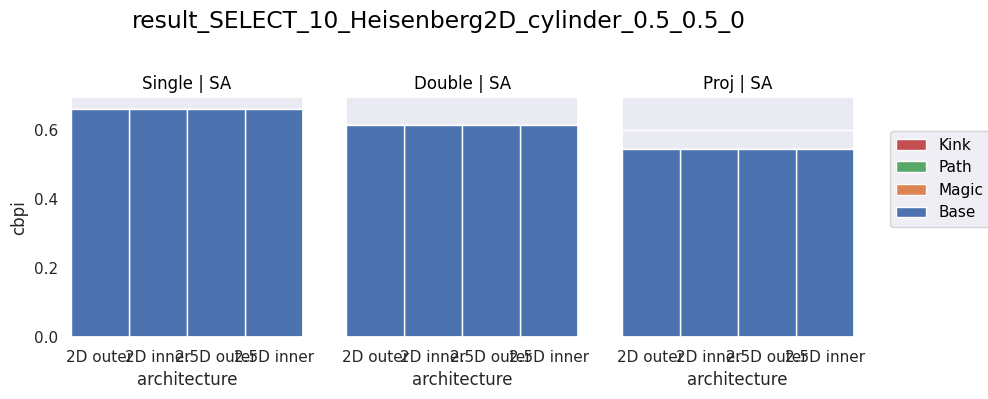

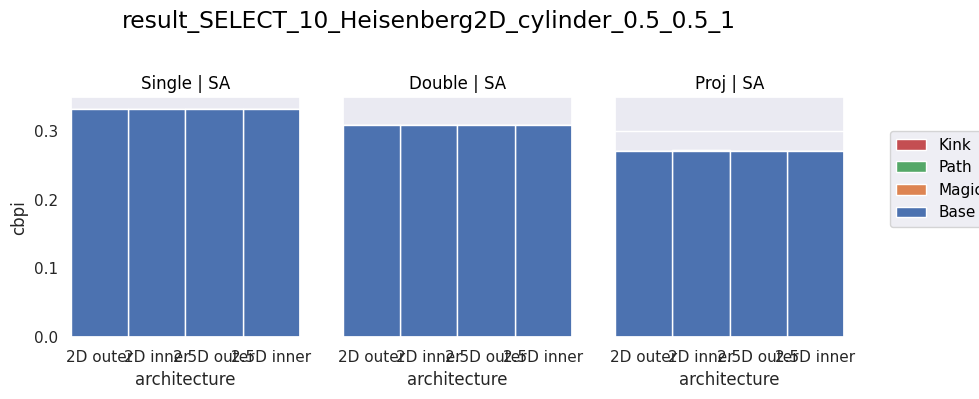

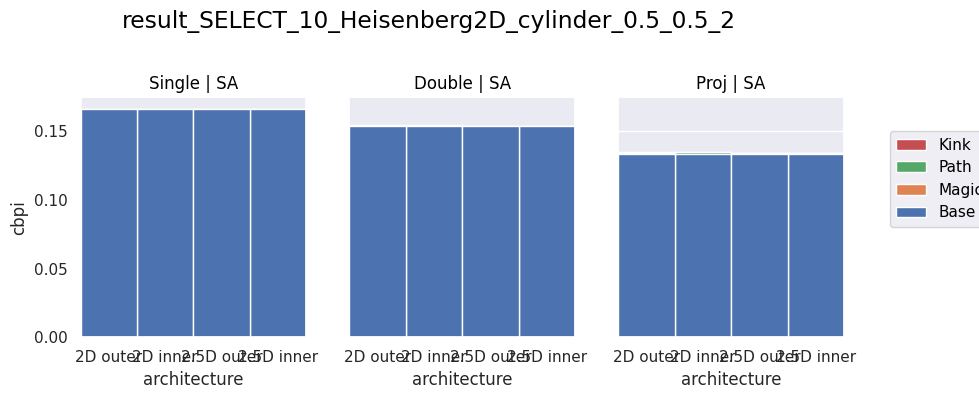

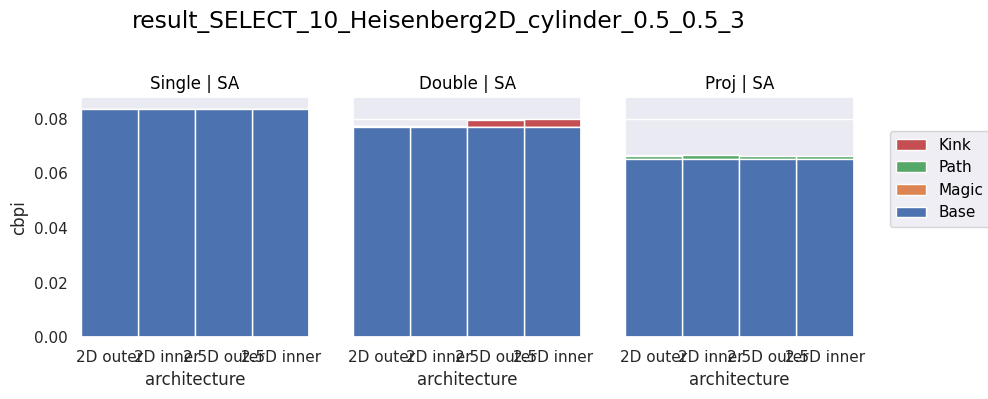

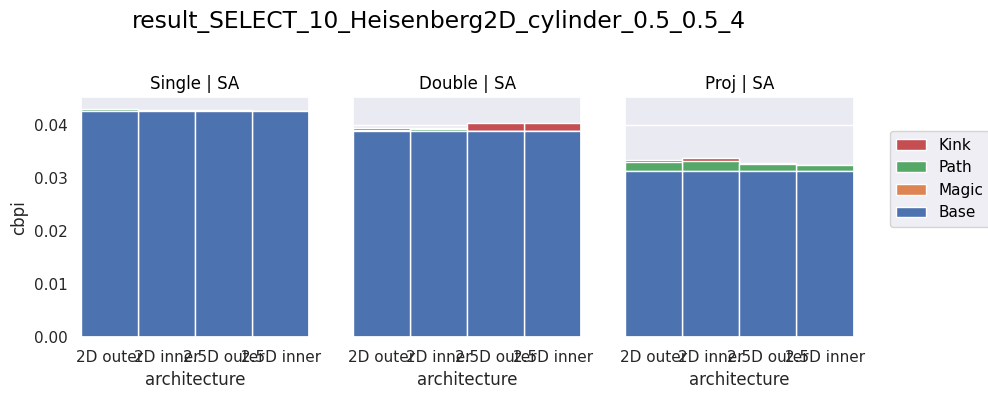

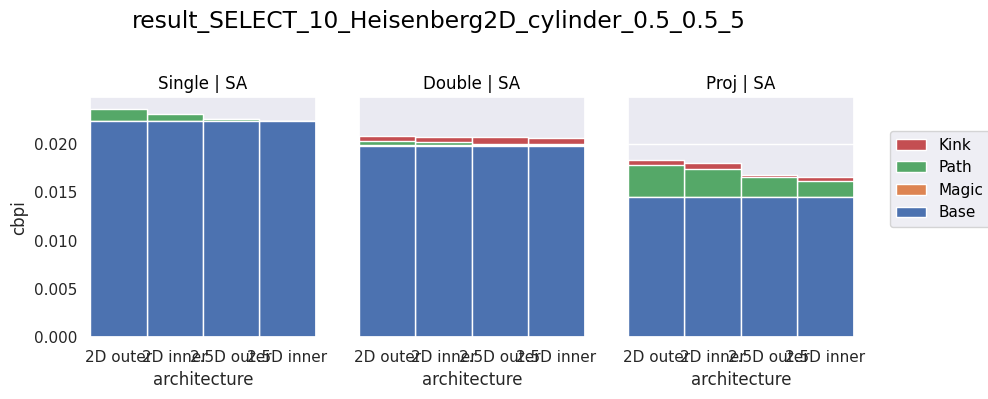

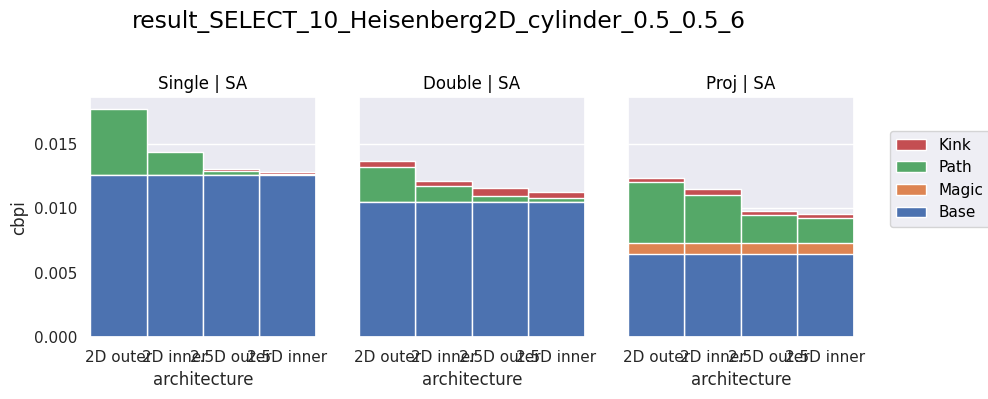

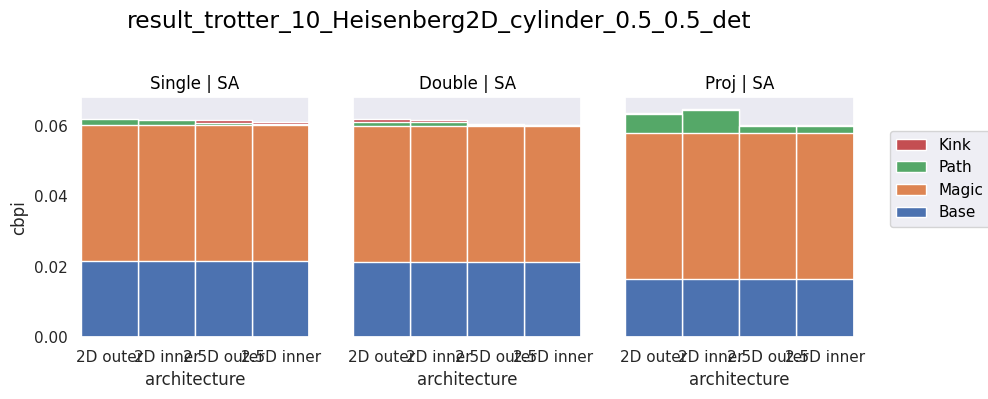

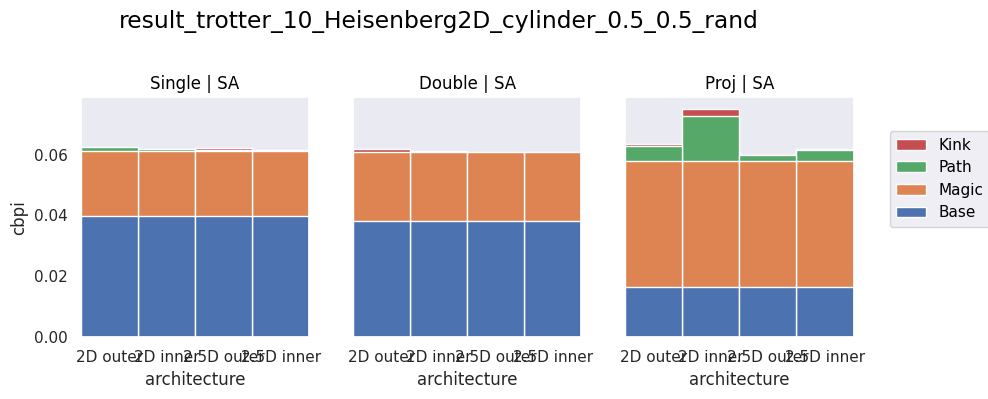

In [ ]:
compare_architecture(df_best_prep_2)

## Circuit Volume

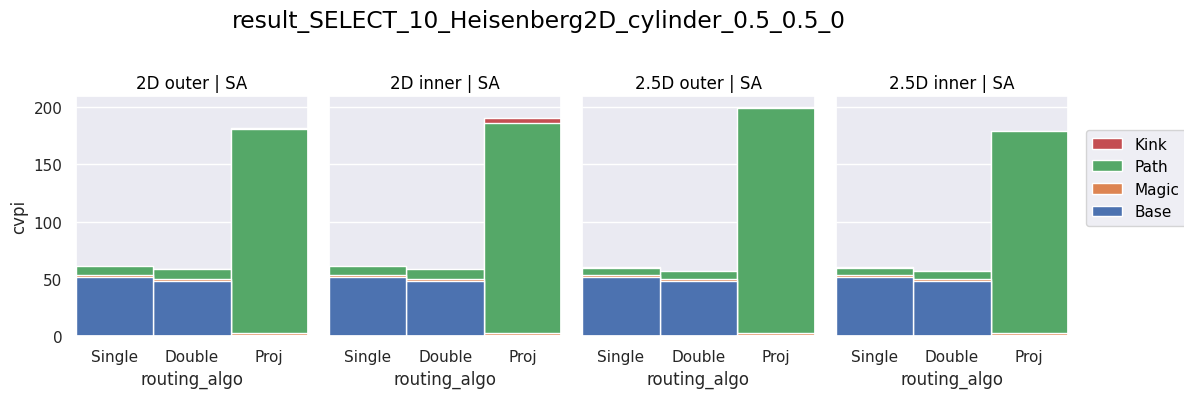

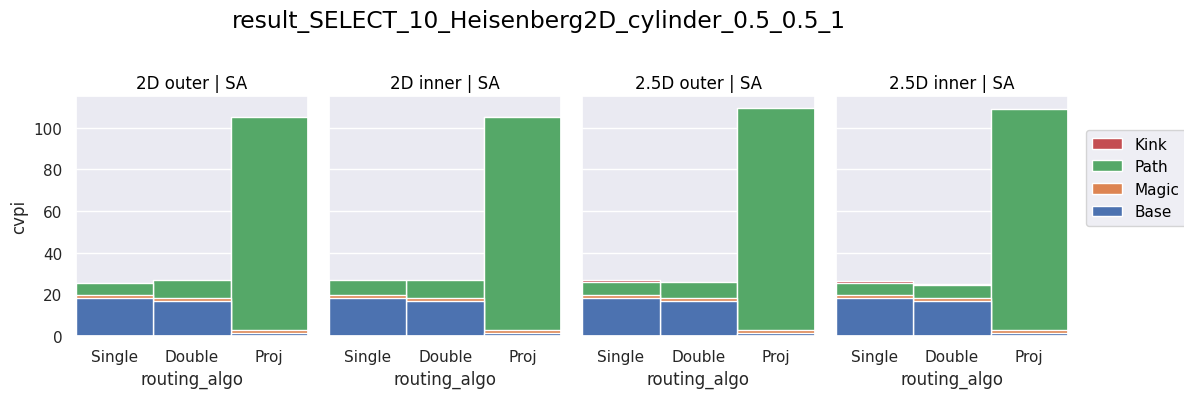

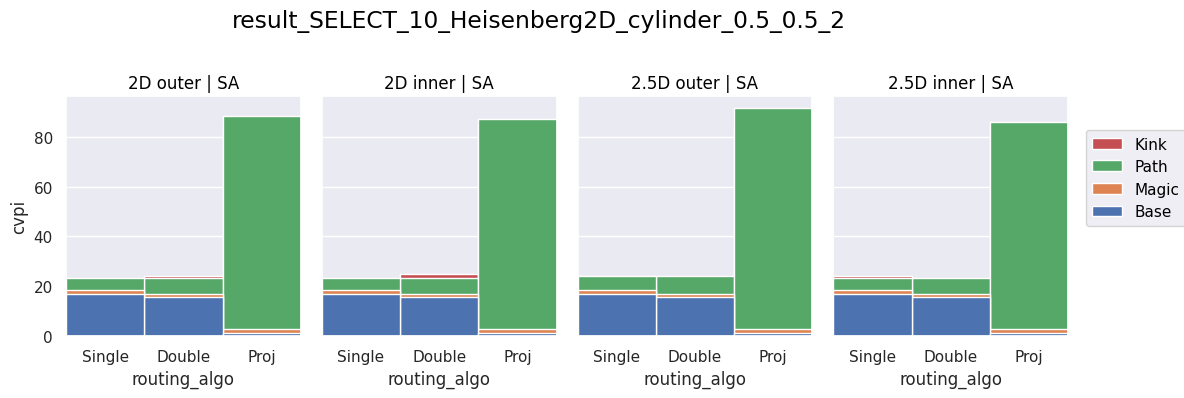

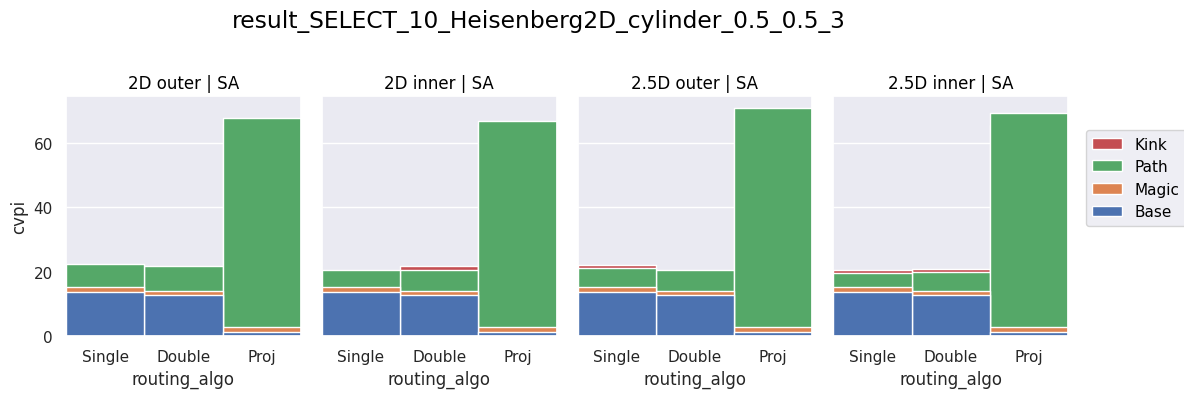

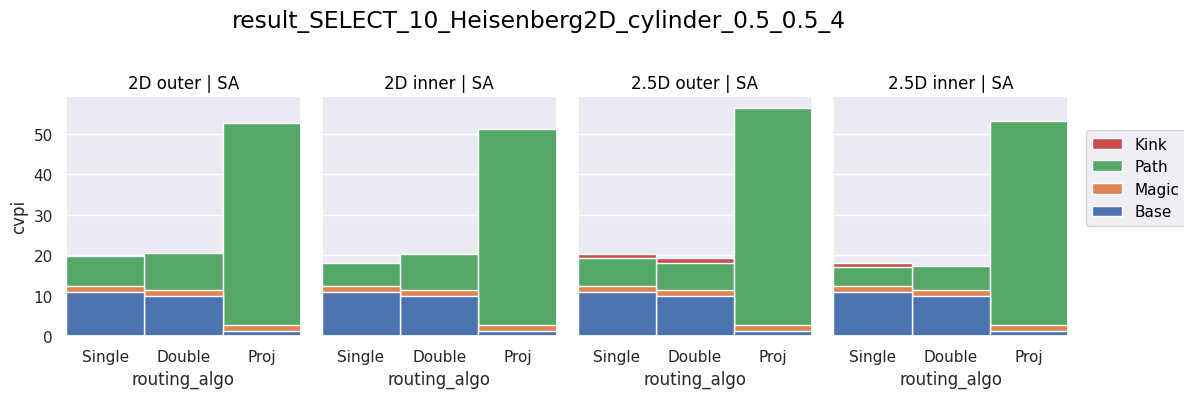

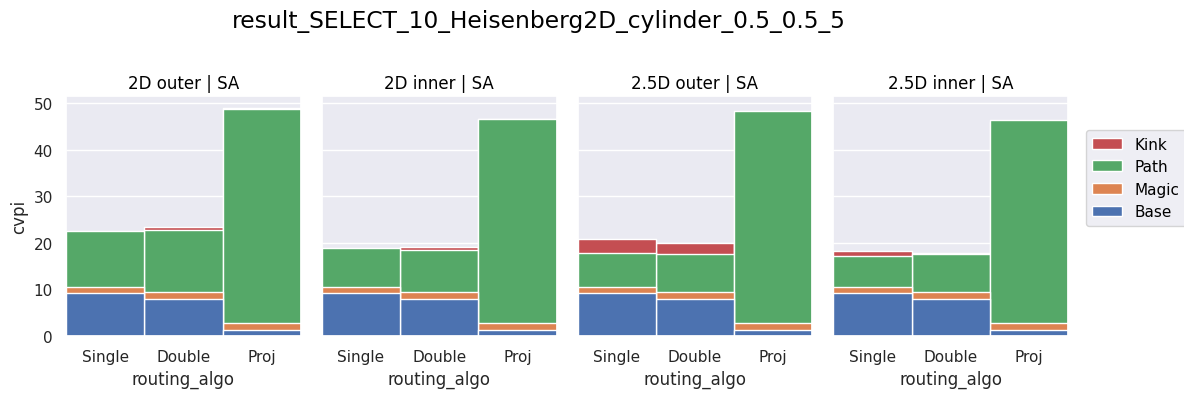

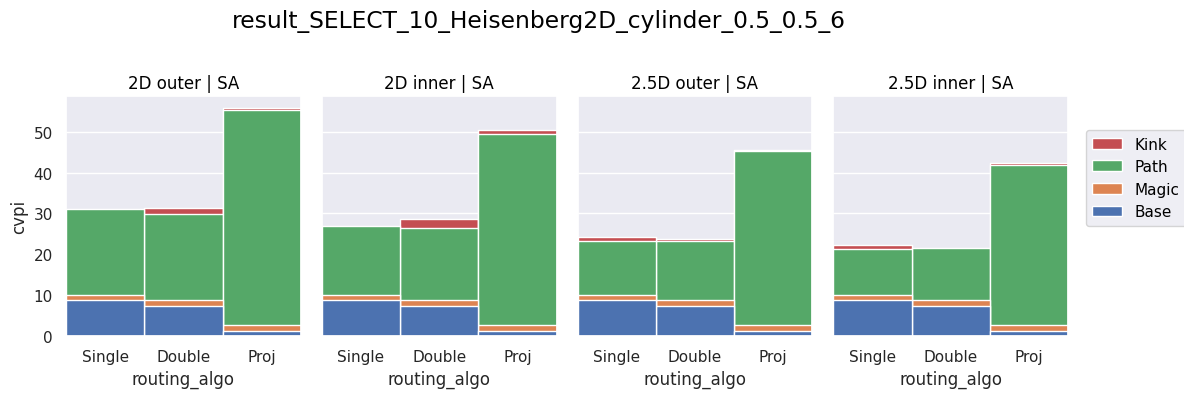

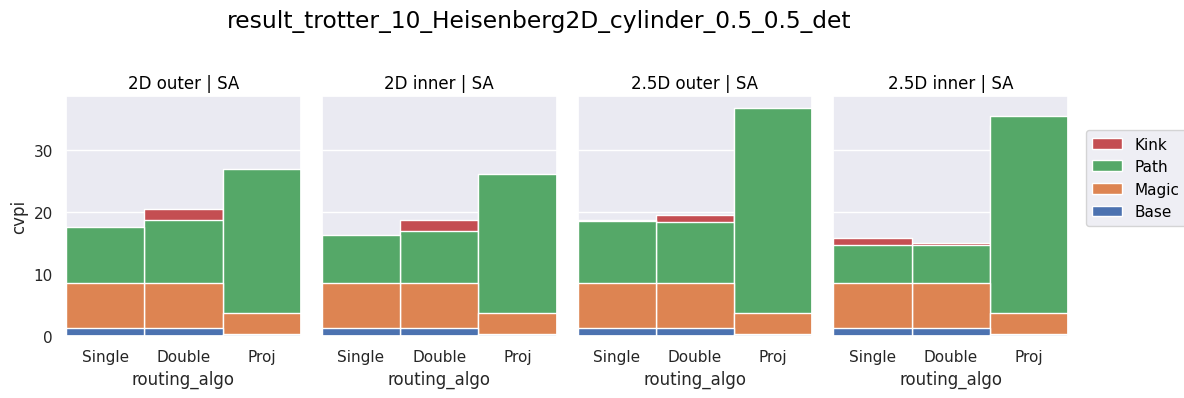

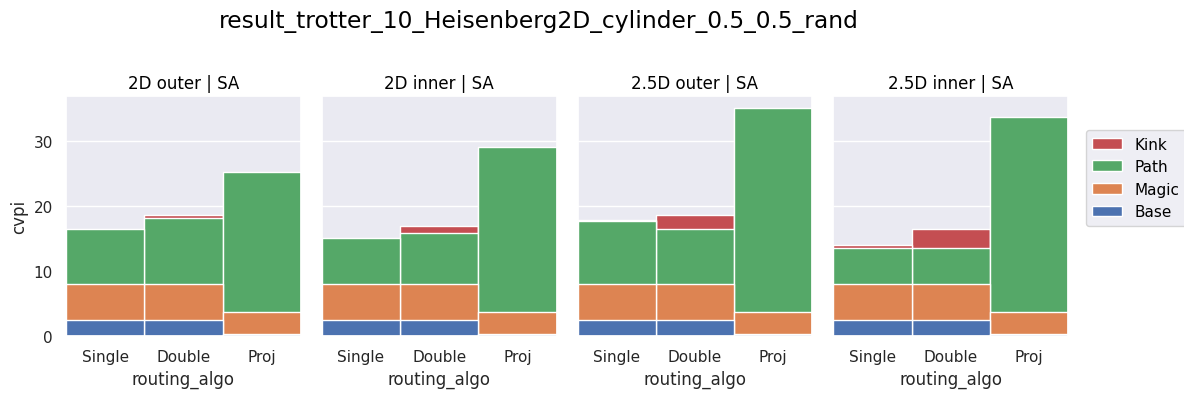

In [ ]:
compare_routing(
    df_best_prep_2,
    "cvpi",
    "../../fig/cv_stack_sns/compare_routing",
)

## Magic Prep Modified

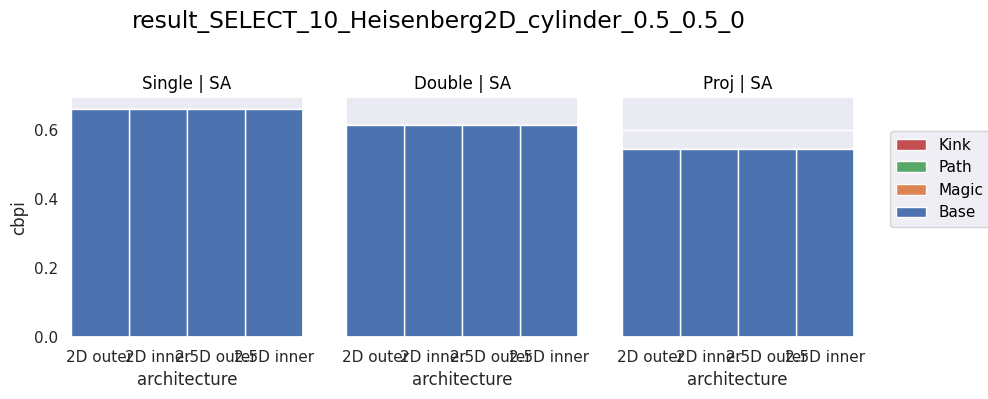

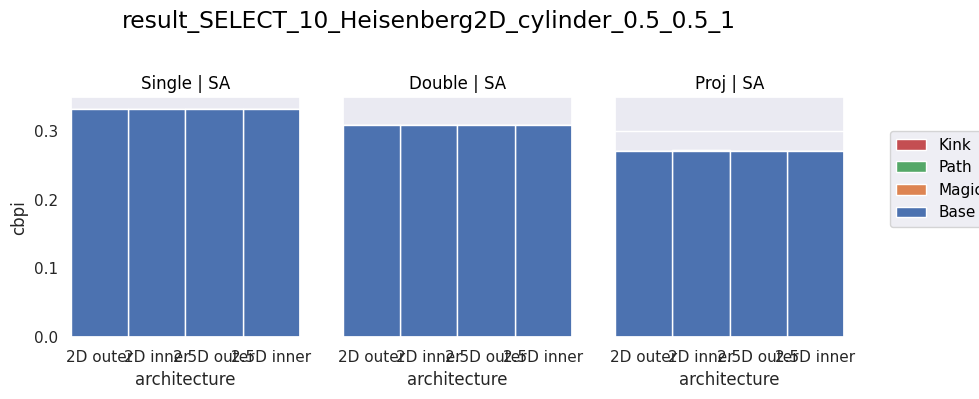

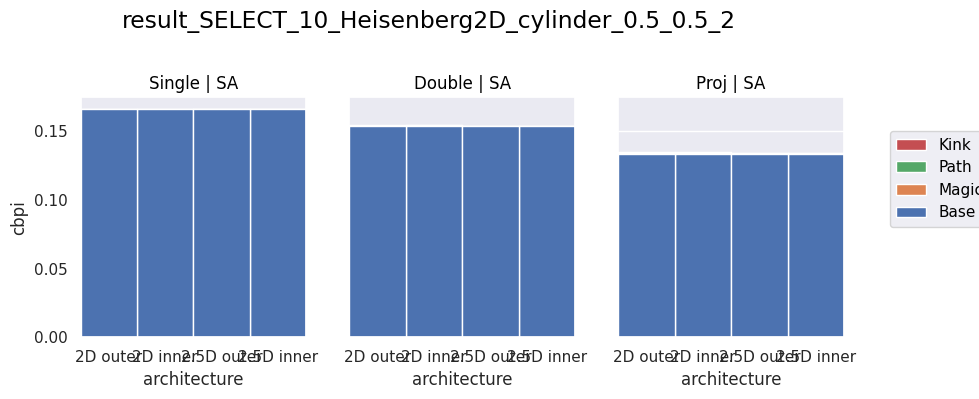

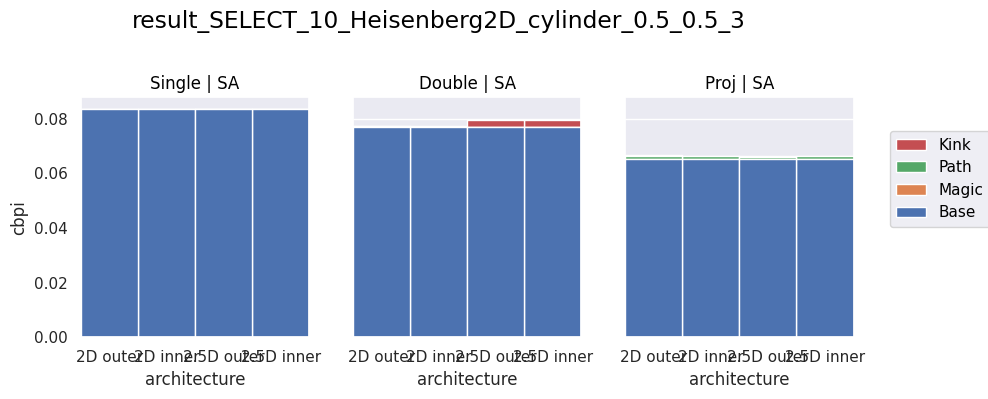

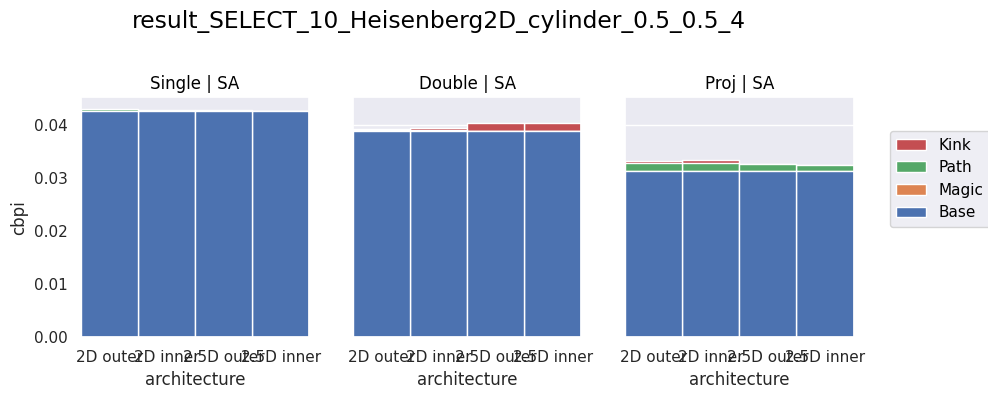

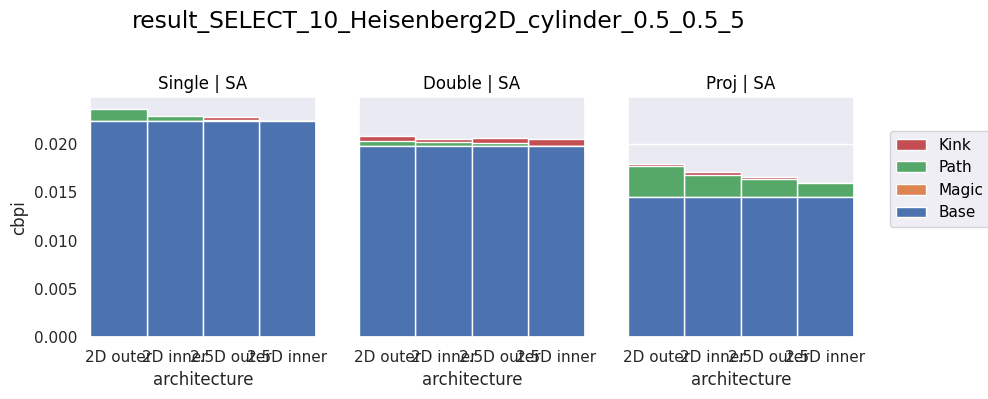

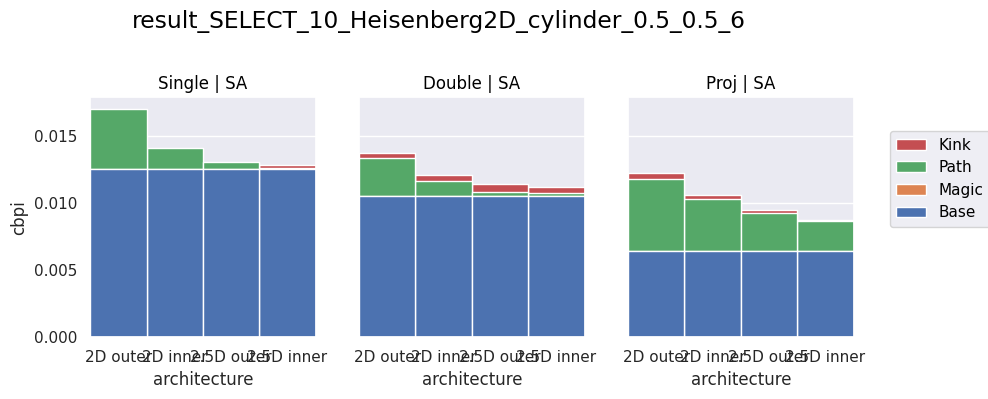

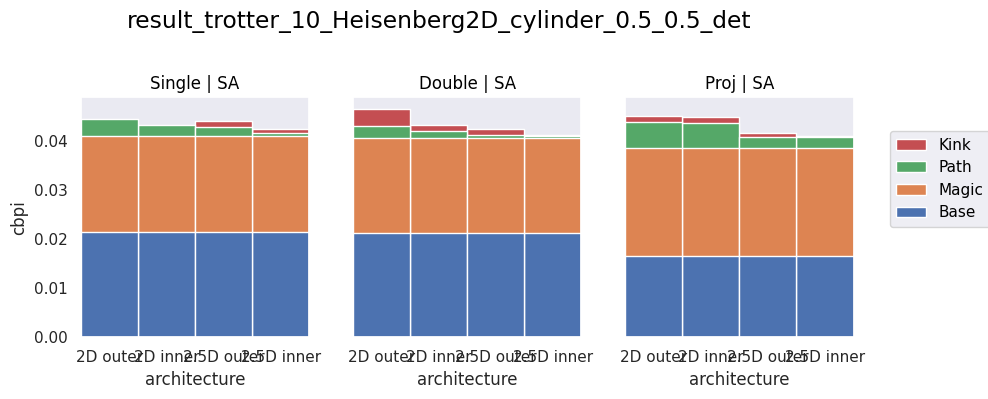

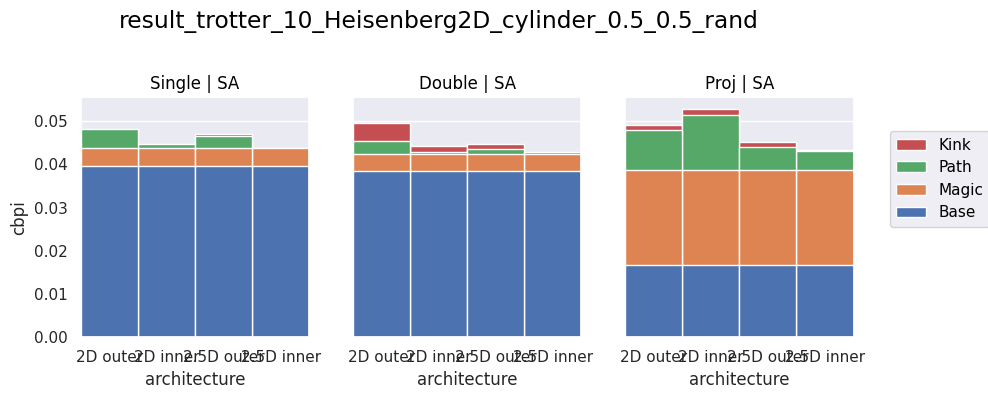

In [ ]:
compare_architecture(df_best_prep_1, "../../fig/cbpi_stack_sns/compare_archi_prep_1")

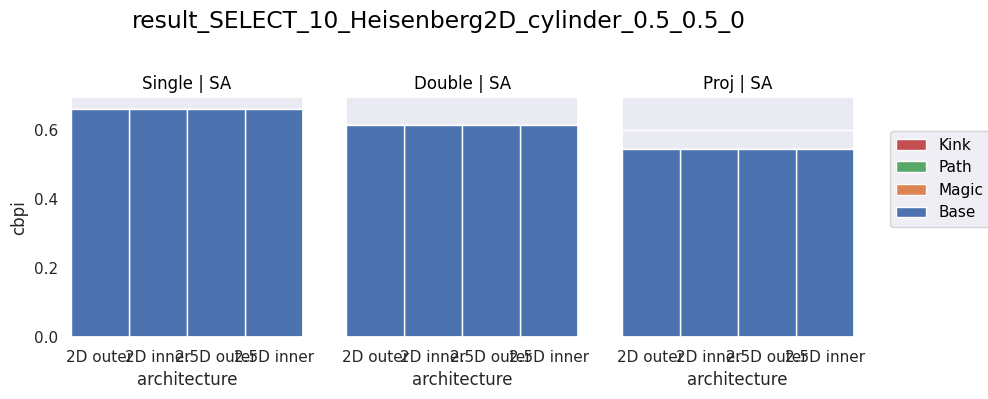

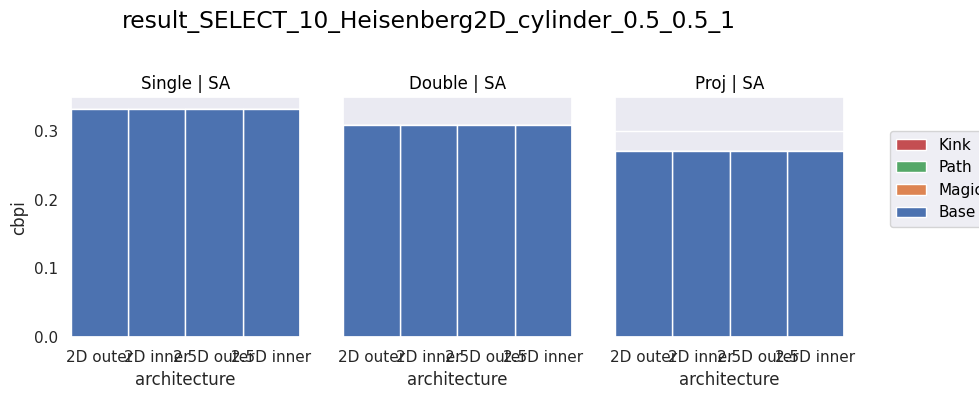

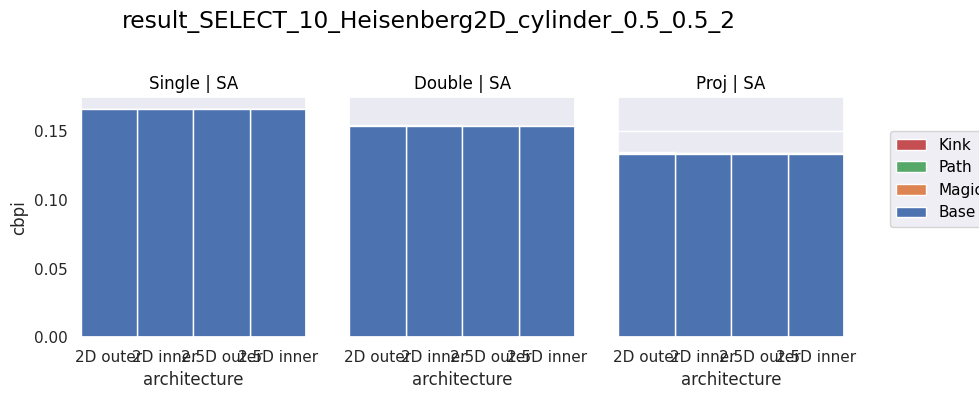

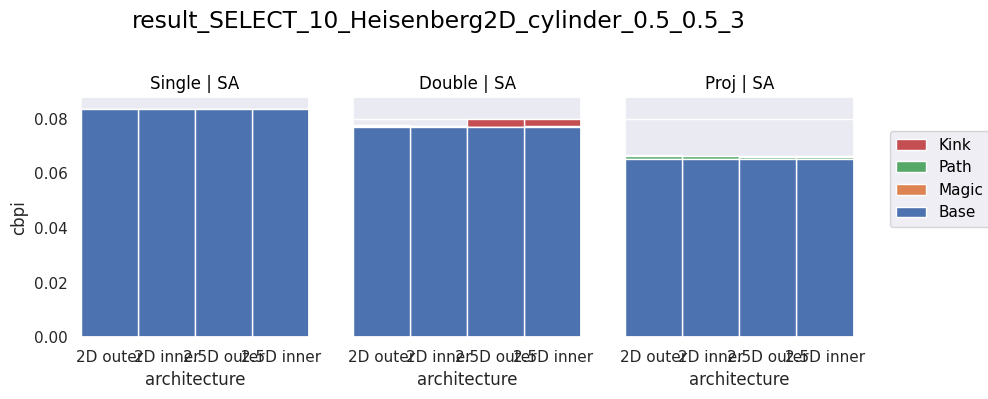

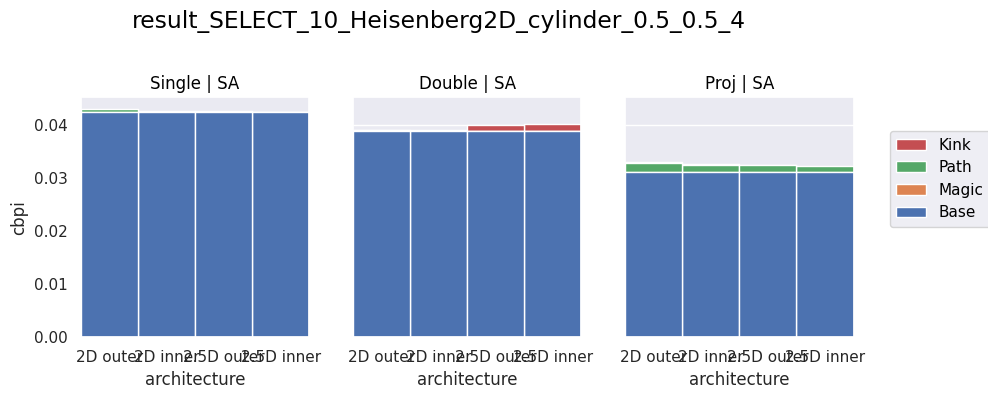

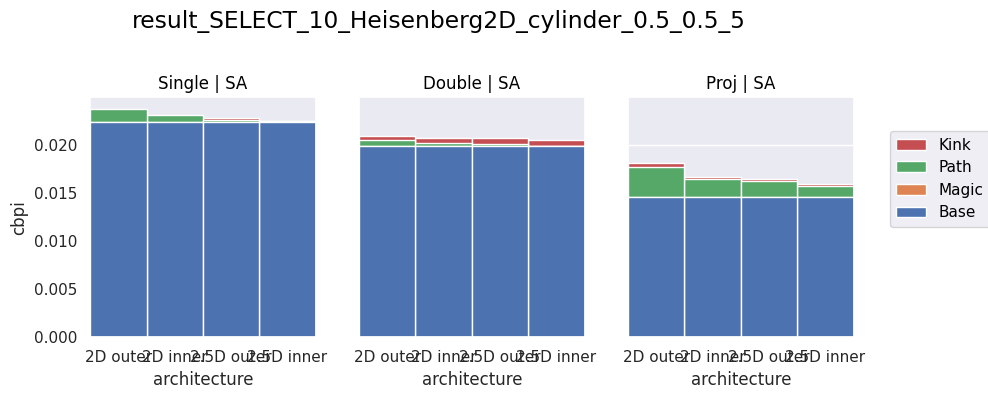

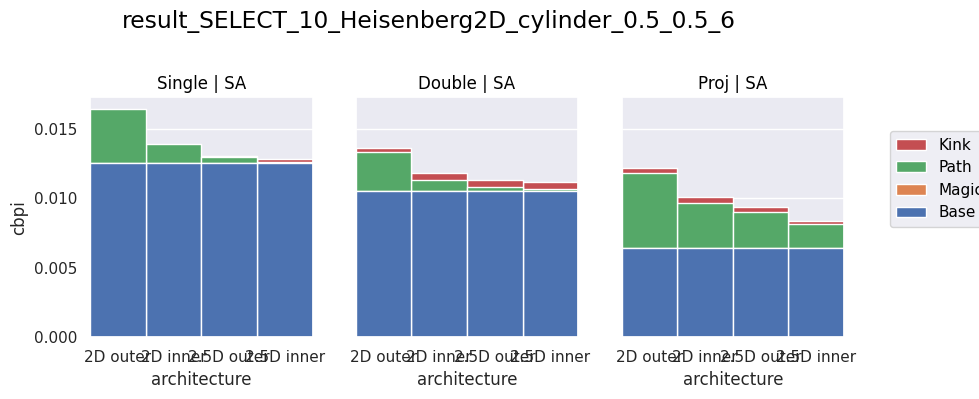

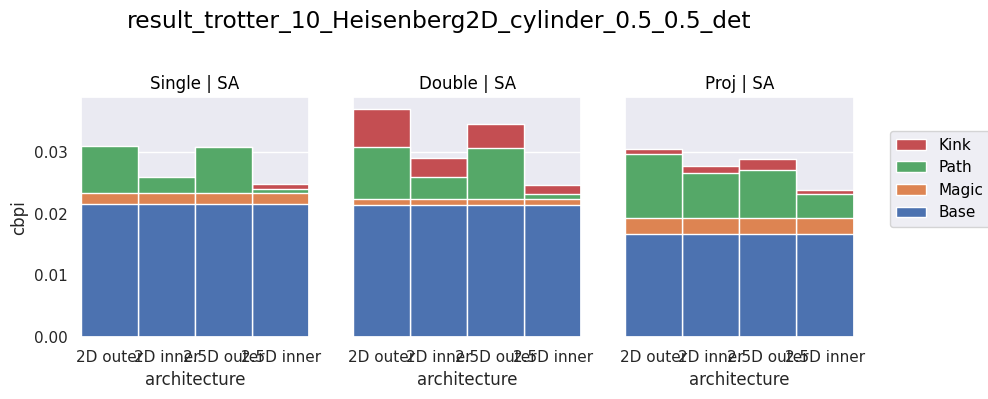

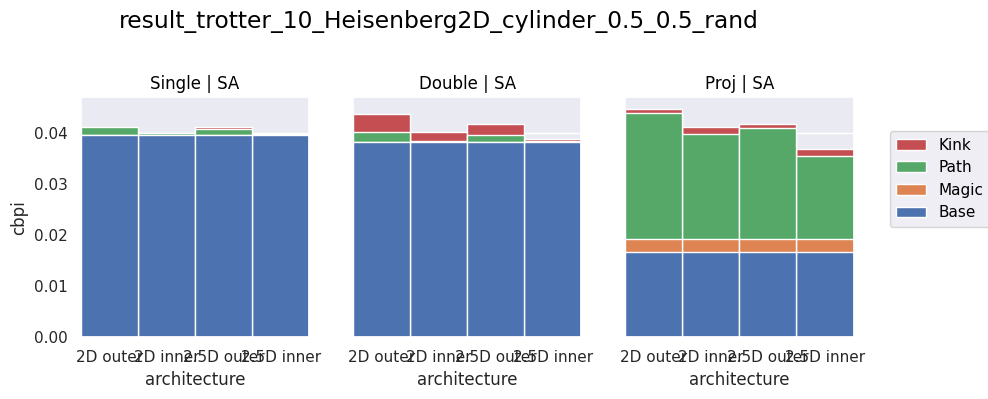

In [ ]:
compare_architecture(df_best_prep_0, "../../fig/cbpi_stack_sns/compare_archi_prep_0")

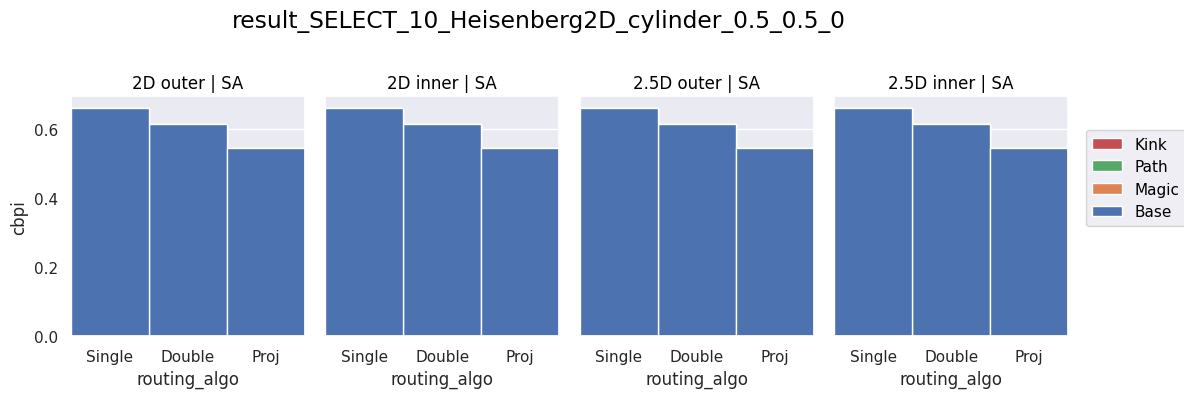

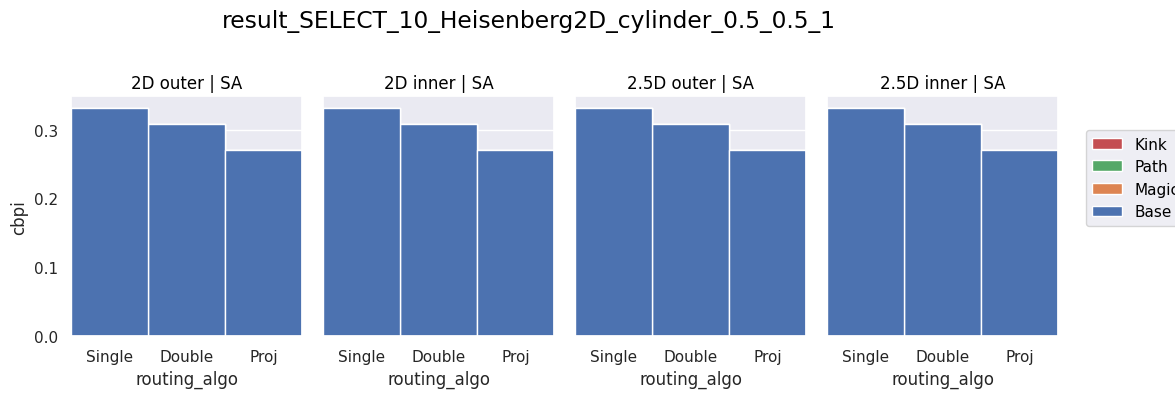

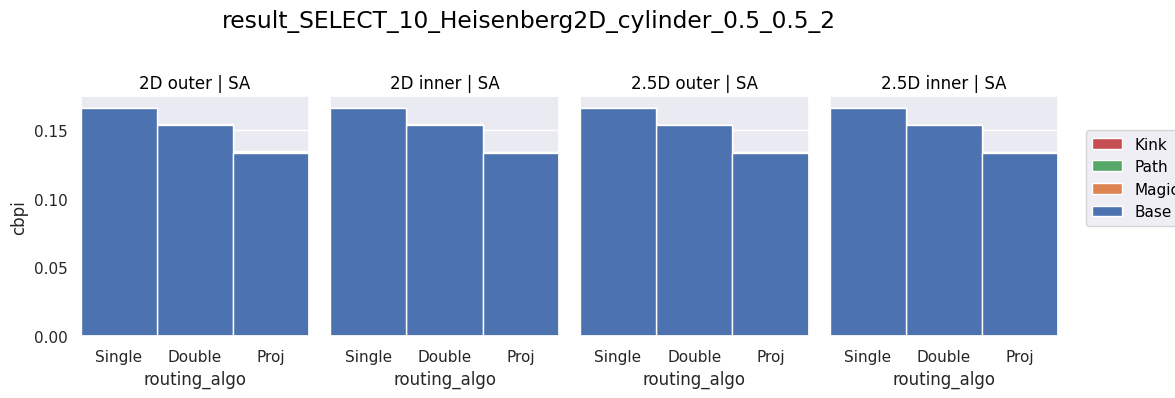

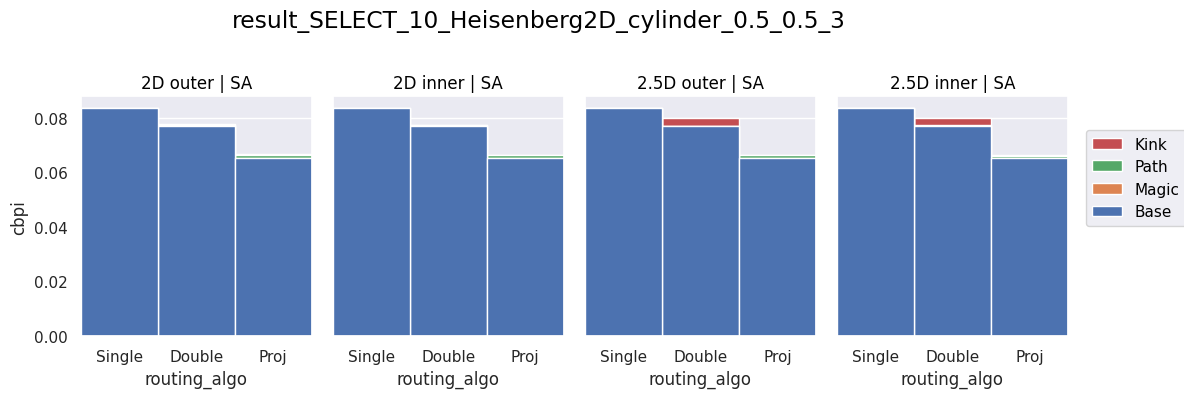

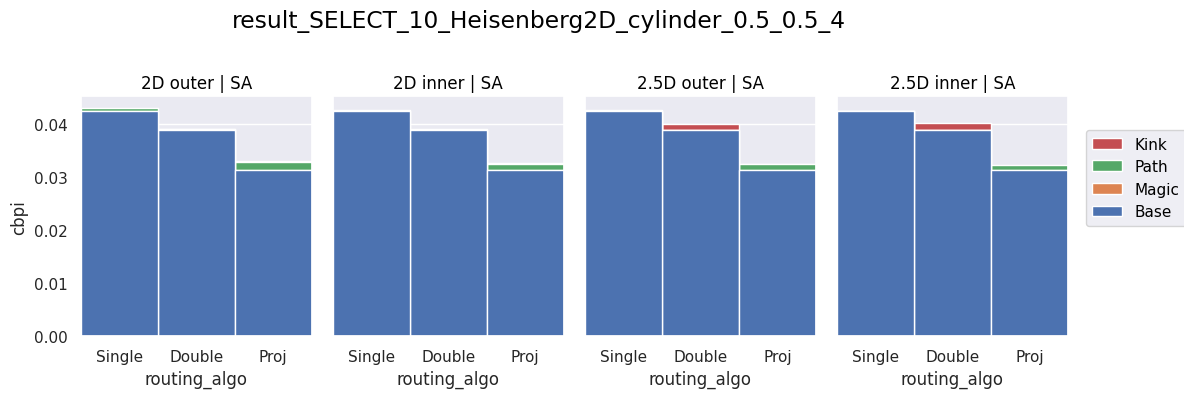

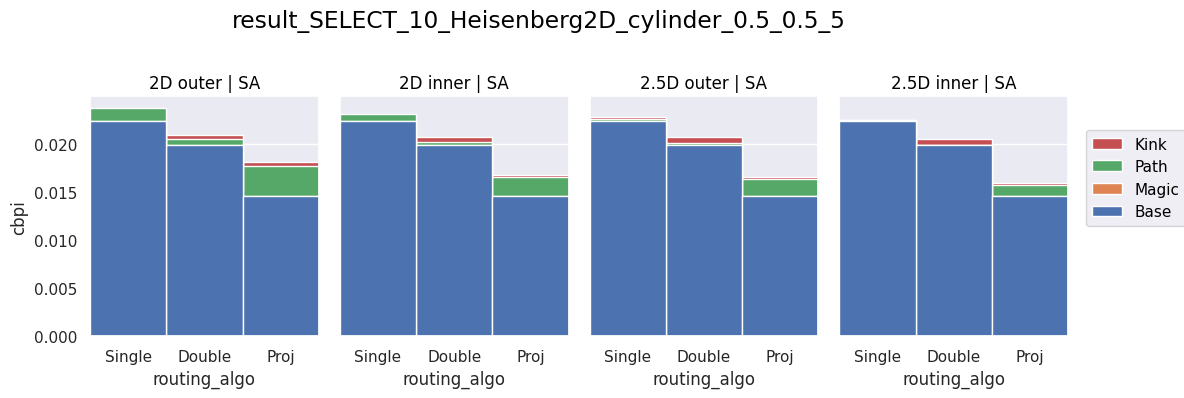

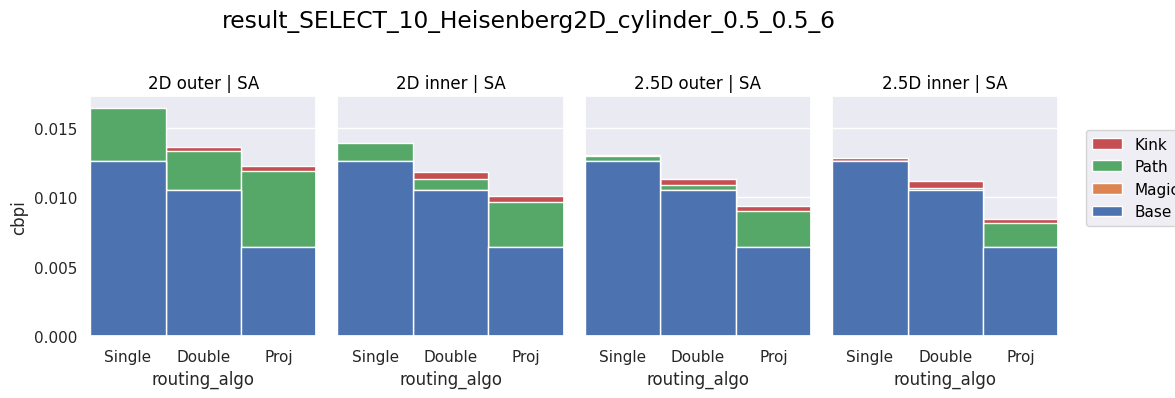

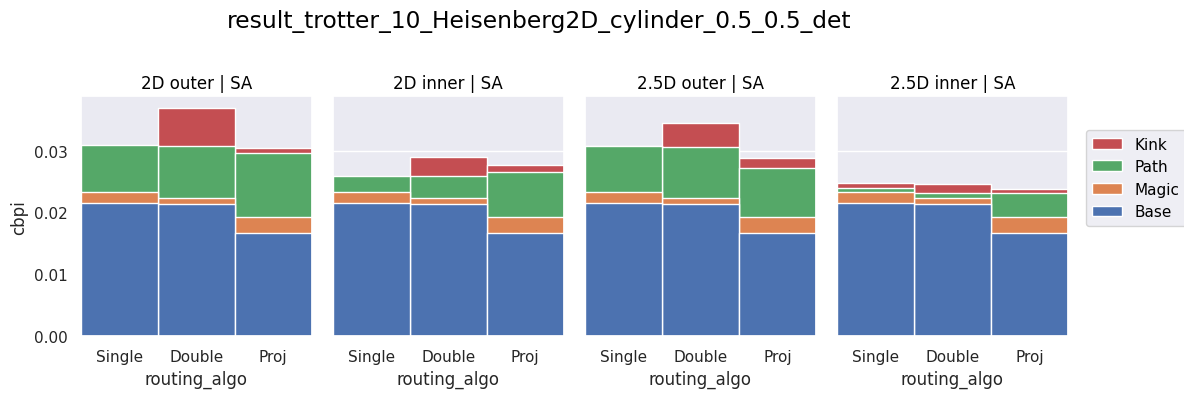

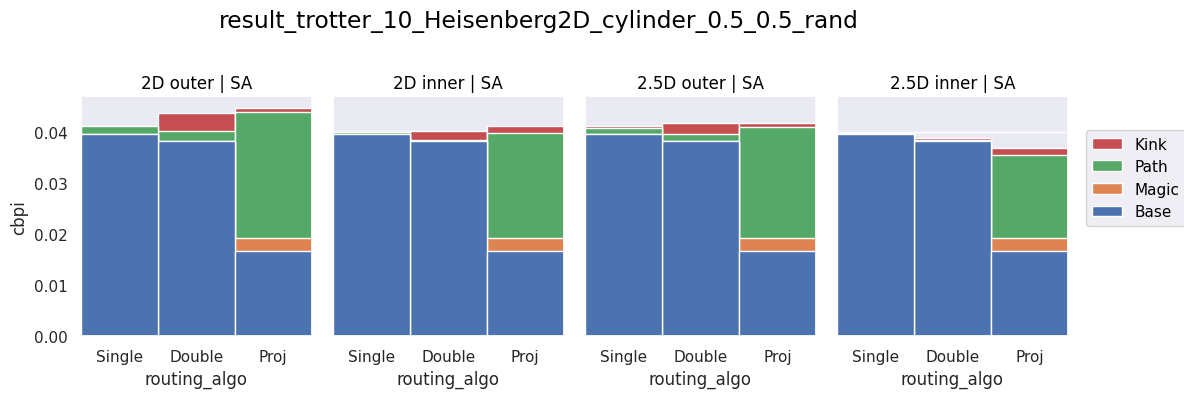

In [ ]:
compare_routing(df_best_prep_0, "../../fig/cbpi_stack_sns/compare_routing_prep_0")